# Examine version 3 of the catalog with amplitudes 

This notebook is used to check whether the amplitude information is correctly added to version 3 of the pick assignment table. 

By Hiroto Bito

In [ ]:
import os
import sys
import pandas as pd
import numpy as np

from obspy.core import UTCDateTime
import time
from obspy.core.stream import Stream
import matplotlib.pyplot as plt
from tqdm import tqdm


parent_dir = '/home/hbito/cascadia_obs_ensemble/utils'
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from data_client import get_waveforms

In [ ]:
datasets_dir =  '/wd1/hbito_data/data/datasets_all_regions'
path_assigned_picks_df = f'{datasets_dir}/Cascadia_updated_catalog_picks_assignment_ver_3_w_amp_test.csv'
assigned_picks_df = pd.read_csv(path_assigned_picks_df, index_col=False)

In [ ]:
skipped_csv_path = f'{datasets_dir}/calculate_amplitudes_skipped_picks_test.csv'
skipped_picks_df = pd.read_csv(skipped_csv_path)

In [ ]:
dir_plots = datasets_dir+'/plot_examine_amp_calculation_filter_st_starttime_calc_from_time_pick'
os.makedirs(name=dir_plots, exist_ok=True)

In [ ]:
# Print the number of rows of assigned_picks_df and the first 10 rows
print("Number of rows: ", len(assigned_picks_df))
assigned_picks_df.head(10)

Number of rows:  1004335


,Unnamed: 0,time_pick,station,phase,timeres,idx,arid,latitude,longitude,depth,Detection Value,time,RMS Residual (s),Num. P,Num. S,picks,slatitude,slongitude,selevation,Amplitude
0,0,2010-01-01T00:15:27.180000Z,UW.PCMD,P,0.049,0,0,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.888962,-122.301483,239.0,534.658499
1,1,2010-01-01T00:15:37.840400Z,UW.RVW,P,1.264,0,1,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.149750,-122.742996,504.0,73.403575
2,2,2010-01-01T00:15:33.280000Z,UW.PCMD,S,-0.243,0,2,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.888962,-122.301483,239.0,897.182138
3,3,2010-01-01T00:15:42.002000Z,UW.GNW,S,2.402,0,3,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.564130,-122.824980,220.0,2239.571065
4,4,2010-01-01T00:15:43.618400Z,PB.B013,S,-0.651,0,4,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.813000,-122.910797,75.3,60.932284
5,5,2010-01-01T00:15:43.768400Z,PB.B943,S,-0.511,0,5,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.813202,-122.911301,84.2,45.608438
6,6,2010-01-01T00:15:48.060400Z,UW.BOW,S,-0.263,0,6,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.474831,-123.229301,870.0,26.518675
7,7,2010-01-01T00:17:04.730000Z,UW.PASS,P,-0.499,1,7,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,48.998299,-122.085197,175.4,240.412236
8,8,2010-01-01T00:17:05.008400Z,PB.B943,P,-0.252,1,8,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,47.813202,-122.911301,84.2,46.170710
9,9,2010-01-01T00:17:05.020400Z,UW.BLN,P,0.415,1,9,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,48.006624,-122.972646,601.0,94.172872


In [ ]:
# Print the number of rows of assigned_picks_df and the first 10 rows
print("Number of rows: ", len(skipped_picks_df))
skipped_picks_df.head(10)

Number of rows:  36391


,network,station,channel,origin_time,time_pick,starttime,endtime,reason
0,UW,VVHS,*H*,2010-04-16T22:48:21.535000Z,2010-04-16T22:48:24.980000Z,2010-04-16T22:48:24.480000Z,2010-04-16T22:48:26.980000Z,Request failed: No Vertical Component Data Pre...
1,CN,HNB,*H*,2010-04-28T14:36:42.921000Z,2010-04-28T14:36:53.940000Z,2010-04-28T14:36:53.440000Z,2010-04-28T14:36:55.940000Z,Request failed: No Vertical Component Data Pre...
2,UW,SP2,*H*,2010-04-30T16:01:16.639000Z,2010-04-30T16:01:35.360000Z,2010-04-30T16:01:34.860000Z,2010-04-30T16:01:37.360000Z,Request failed: No Vertical Component Data Pre...
3,UW,SP2,*H*,2010-04-30T20:11:55.912000Z,2010-04-30T20:12:05.360000Z,2010-04-30T20:12:04.860000Z,2010-04-30T20:12:07.360000Z,Request failed: No Vertical Component Data Pre...
4,UW,SP2,*H*,2010-05-01T04:18:47.446000Z,2010-05-01T04:18:57.850000Z,2010-05-01T04:18:57.350000Z,2010-05-01T04:18:59.850000Z,Request failed: No Vertical Component Data Pre...
5,UW,SP2,*H*,2010-06-22T15:49:24.169000Z,2010-06-22T15:49:37.870000Z,2010-06-22T15:49:37.370000Z,2010-06-22T15:49:39.870000Z,Request failed: No Vertical Component Data Pre...
6,UW,SP2,*H*,2010-06-23T01:10:53.872000Z,2010-06-23T01:11:05.360000Z,2010-06-23T01:11:04.860000Z,2010-06-23T01:11:07.360000Z,Request failed: No Vertical Component Data Pre...
7,UW,SP2,*H*,2010-06-24T09:46:51.644000Z,2010-06-24T09:47:05.420000Z,2010-06-24T09:47:04.920000Z,2010-06-24T09:47:07.420000Z,Request failed: No Vertical Component Data Pre...
8,UW,SP2,*H*,2010-06-27T23:17:12.133000Z,2010-06-27T23:17:27.920000Z,2010-06-27T23:17:27.420000Z,2010-06-27T23:17:29.920000Z,Request failed: No Vertical Component Data Pre...
9,UW,SP2,*H*,2010-07-31T04:04:17.592000Z,2010-07-31T04:05:02.760000Z,2010-07-31T04:05:02.260000Z,2010-07-31T04:05:04.760000Z,Request failed: No Vertical Component Data Pre...


### Make plots to make sure that the amplitude calculation was correct

test

In [ ]:
# assigned_picks_df.iloc[0]['time_pick']

'2010-01-01T00:15:27.180000Z'

In [ ]:
# # Define the arguments 
# row = assigned_picks_df.iloc[0]
# window_before = 0.5
# window_after = 2

# date, _time = row['time'].split(' ')
# datetime_str = date+'T'+_time
# origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly

# time_pick_str = row['time_pick'] 
# time_pick = UTCDateTime(time_pick_str)  # Accept ISO string directly

# network = row['station'].split('.')[0].strip()
# station = row['station'].split('.')[1].strip()
# channel = '*H*'
# starttime = time_pick - window_before 
# endtime = time_pick + window_after

# source = 'pnwstore'
 

# # Request a waveform
# time.sleep(0.1)

# # Request a waveform
# time.sleep(0.1)

# try:
#     st = get_waveforms(network=network, station=station, channel=channel,
#                         starttime=starttime, endtime=endtime,
#                         source=source)
# except Exception as e:
#     print(f"Request failed: {e}")

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


endtest

In [ ]:
# Function to plot waveforms using Obspy bulk request
def plot_waveforms_for_picks(assigned_picks_df, dir_plots, window_before=30, window_after=120, window_amp_calc_before=0.5, window_amp_calc_after=2, n_picks=10, source='pnwstore', scaling_factor_vline=0.1):

    # Prepare the lists
    bulk = []
    pick_info = []
    ls_idx = np.random.choice(a=len(assigned_picks_df), size=(n_picks))
    # ls_idx = np.arange(n_picks)
    
    # for i, row in assigned_picks_df.head(n_picks).iterrows():
    for i in range(len(ls_idx)):
        orid = assigned_picks_df.iloc[ls_idx[i]]['idx']
        pick_id = assigned_picks_df.iloc[ls_idx[i]]['arid']
      
        date, _time = assigned_picks_df.iloc[ls_idx[i]]['time'].split(' ')
        datetime_str = date+'T'+_time
        origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
        latitude = assigned_picks_df.iloc[ls_idx[i]]['latitude']
        longitude = assigned_picks_df.iloc[ls_idx[i]]['longitude']
        depth = assigned_picks_df.iloc[ls_idx[i]]['depth']
        
        # You may need to adjust these fields to match your DataFrame columns
        network = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[0].strip()
        station = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[1].strip()
        channel = "*H*"
        time_pick = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick'])
        time_pick_origin  = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick']) - origin_time
        starttime = time_pick - window_before 
        endtime = time_pick + window_after
        phase = assigned_picks_df.iloc[ls_idx[i]]['phase']
        amp = assigned_picks_df.iloc[ls_idx[i]]['Amplitude']

        bulk.append((network, station, channel, starttime, endtime))
        pick_info.append({
            'orid': orid,
            'pick_id': pick_id,
            'origin_time': origin_time,
            'latitude': latitude,
            'longitude': longitude,
            'depth': depth,
            'network': network,
            'station': station,
            'channel': channel,
            'starttime': starttime,
            'endtime': endtime,
            'time_pick': time_pick,
            'time_pick_origin': time_pick_origin,
            'phase': phase,
            'amp': amp
        })


    # Parameters to process waveforms
    new_sampling_rate = 100 # in Hz
    # freqmax = 15 # in Hz
    # freqmin = 4 # in Hz
    freq_highpass = 2 # in Hz


    # Plotting
    for i, info in enumerate(pick_info):

        network = pick_info[i]['network']
        station = pick_info[i]['station']
        channel = pick_info[i]['channel']
        starttime = pick_info[i]['starttime']
        endtime = pick_info[i]['endtime']
        amp = pick_info[i]['amp']

        time_pick = pick_info[i]['time_pick']
        time_pick_origin = pick_info[i]['time_pick_origin']

        fname = dir_plots+f"/{network}_{station}_arid_{info['pick_id']}.png"

        time.sleep(0.1)

        try:
            st = get_waveforms(
                network=network,
                station=station,
                channel=channel,
                starttime=starttime,
                endtime=endtime,
                source=source
            )
        except Exception as e:
            print(f"Request failed: {e}")
            st = Stream()

        time.sleep(0.1)

        # ---------------------------------------------------------
        # Select preferred channel family
        # ---------------------------------------------------------

        has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
        has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
        has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

        sdata = Stream()

        if has_HH:
            sdata += st.select(id=f'{network}.{station}..HH*')
            channel_prefix = "HH"

        elif has_BH:
            sdata += st.select(id=f'{network}.{station}..BH*')
            channel_prefix = "BH"

        elif has_EH:
            sdata += st.select(id=f'{network}.{station}..EH*')
            channel_prefix = "EH"

        else:
            print(f'No HH, BH, or EH data available at {network}.{station} at {time_pick}. Skipping.')
            continue

        #---Debug---#

        sdata.resample(new_sampling_rate)

        sdata.detrend(type='demean')
        sdata.taper(max_percentage=0.05)
        sdata.filter(type='highpass', freq=freq_highpass)

        max_amp = 0
        for tr in sdata:
            print('First print of max_amp',max_amp)
            print('np.max(np.absolute(tr.data))',np.max(np.absolute(tr.data)))
            
            max_amp = max(max_amp, np.absolute(tr.data).max())
            
            print('Second print of max_amp',max_amp)

        #---End debug---#

        # ---------------------------------------------------------
        # Create figure with 3 components
        # ---------------------------------------------------------

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 8),
            sharex=True
        )

        component_list = ['Z', '[N2]', '[E1]']

        for ax, comp in zip(axes, component_list):

            tr_select = sdata.select(channel=f"{channel_prefix}{comp}")

            # -----------------------------------------------------
            # Leave blank if component does not exist
            # -----------------------------------------------------

            if len(tr_select) == 0:

                ax.set_title(f"{channel_prefix}{comp} : No Data")
                ax.grid()

                continue

            tr = tr_select[0].copy()

            # -----------------------------------------------------
            # Process waveform
            # -----------------------------------------------------

            data = tr.data

            times = np.linspace(
                -window_before,
                window_after,
                tr.stats.npts
            )

            # print('times', times)
            time_vline = 0

            ymax = np.max(np.abs(data)) * scaling_factor_vline
            ymin = -np.max(np.abs(data)) * scaling_factor_vline

            xmax = time_vline + window_amp_calc_after
            xmin = time_vline - window_amp_calc_before

            # -----------------------------------------------------
            # Plot waveform
            # -----------------------------------------------------

            ax.axvspan(
                xmin,
                xmax,
                color='b',
                alpha=0.2
            )

            ax.plot(times, data)

            ax.vlines(
                time_vline,
                ymin,
                ymax,
                color='k',
                linestyles='solid'
            )

            ax.hlines(
                amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.hlines(
                -amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.set_ylabel(comp)
            ax.grid()

        # ---------------------------------------------------------
        # Common formatting
        # ---------------------------------------------------------

        axes[0].set_title(
            f"Origin ID: {info['orid']} | "
            f"Pick ID: {info['pick_id']} | "
            f"Network: {info['network']} | "
            f"Station: {info['station']} | "
            f"Channel: {channel_prefix} | "
            f"Phase: {info['phase']}"
        )

        axes[-1].set_xlabel("Time (s) from Origin Time")

        ticks = np.arange(-window_before, window_after, 10)
        str_ticks = [str(t) for t in ticks]

        axes[-1].set_xticks(ticks=ticks, labels=str_ticks)

        # Event information box
        info_text = (
            f"Origin Time: {info['origin_time']}\n"
            f"Latitude: {info['latitude']}\n"
            f"Longitude: {info['longitude']}\n"
            f"Depth: {info['depth']}\n"
            f"Amplitude: {np.round(amp, decimals=1)}"
        )

        props = dict(
            boxstyle='round',
            facecolor='wheat',
            alpha=0.5
        )

        axes[0].text(
            0.98,
            0.98,
            info_text,
            transform=axes[0].transAxes,
            fontsize=10,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=props
        )

        plt.tight_layout()
        plt.show()
        plt.savefig(fname=fname, format='png')
        plt.close(fig)

        time.sleep(0.1)



In [ ]:
# Define the variables in the function
window_before = 30 # in sec
window_after = 150 # in sec
window_amp_calc_before=0.5 # in sec
window_amp_calc_after=2 # in sec
n_picks = 20
source = 'pnwstore'
scaling_factor_vline = 0.3

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 1057.077520313439
Second print of max_amp 1057.077520313439
First print of max_amp 1057.077520313439
np.max(np.absolute(tr.data)) 9.045911227452589
Second print of max_amp 1057.077520313439


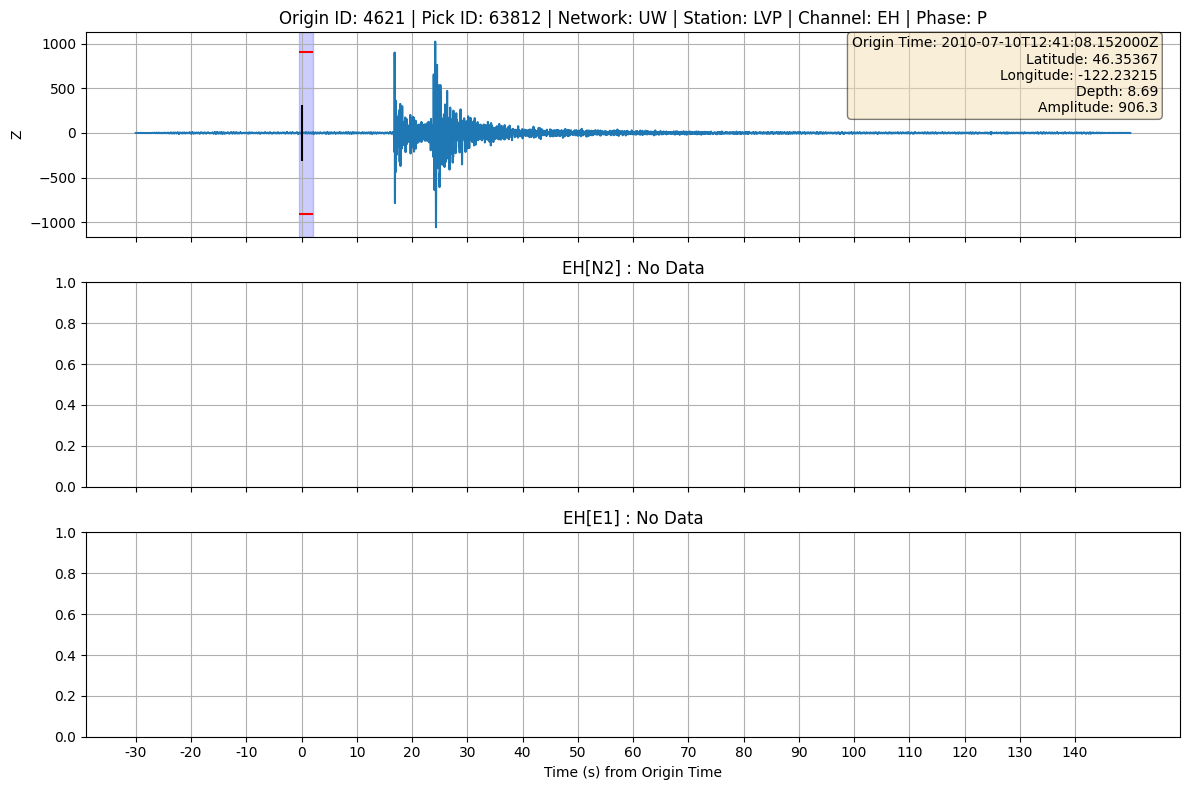

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 59.899208073227314
Second print of max_amp 59.899208073227314
First print of max_amp 59.899208073227314
np.max(np.absolute(tr.data)) 44.91702674412794
Second print of max_amp 59.899208073227314
First print of max_amp 59.899208073227314
np.max(np.absolute(tr.data)) 47.375026684418295
Second print of max_amp 59.899208073227314


<Figure size 640x480 with 0 Axes>

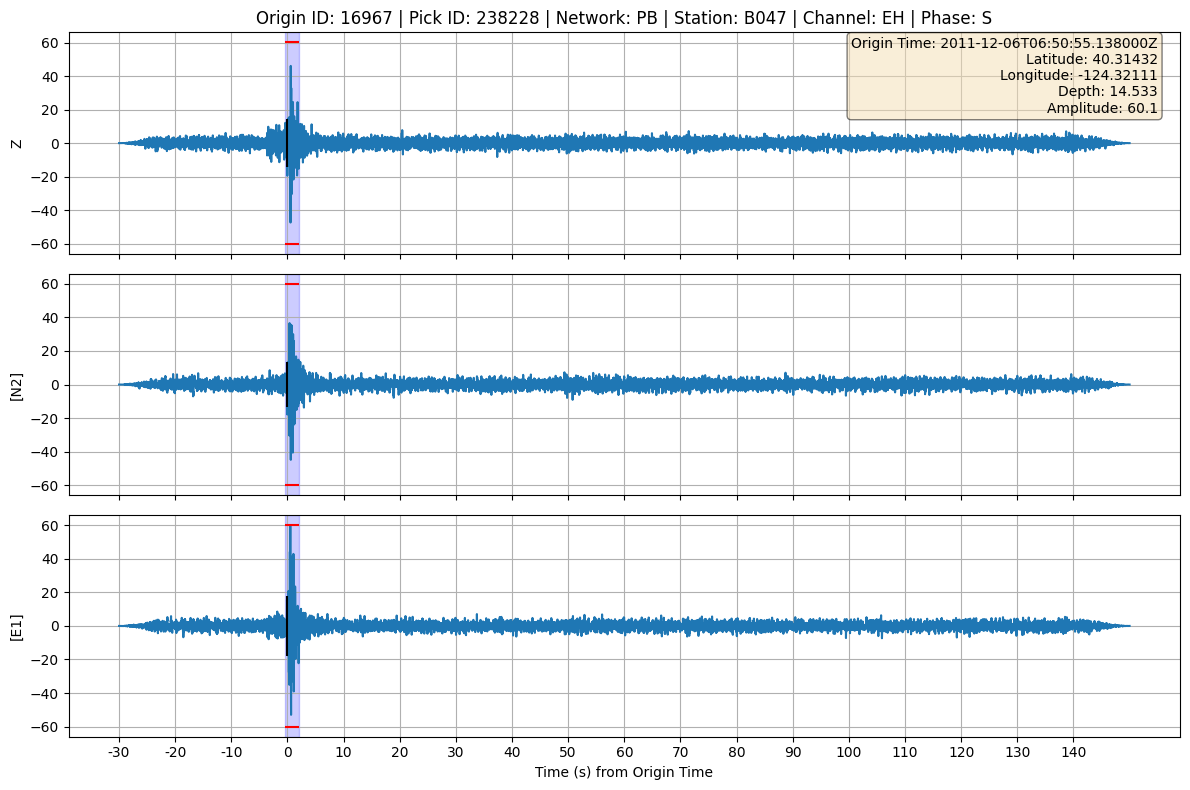

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 45156.545714288266
Second print of max_amp 45156.545714288266


<Figure size 640x480 with 0 Axes>

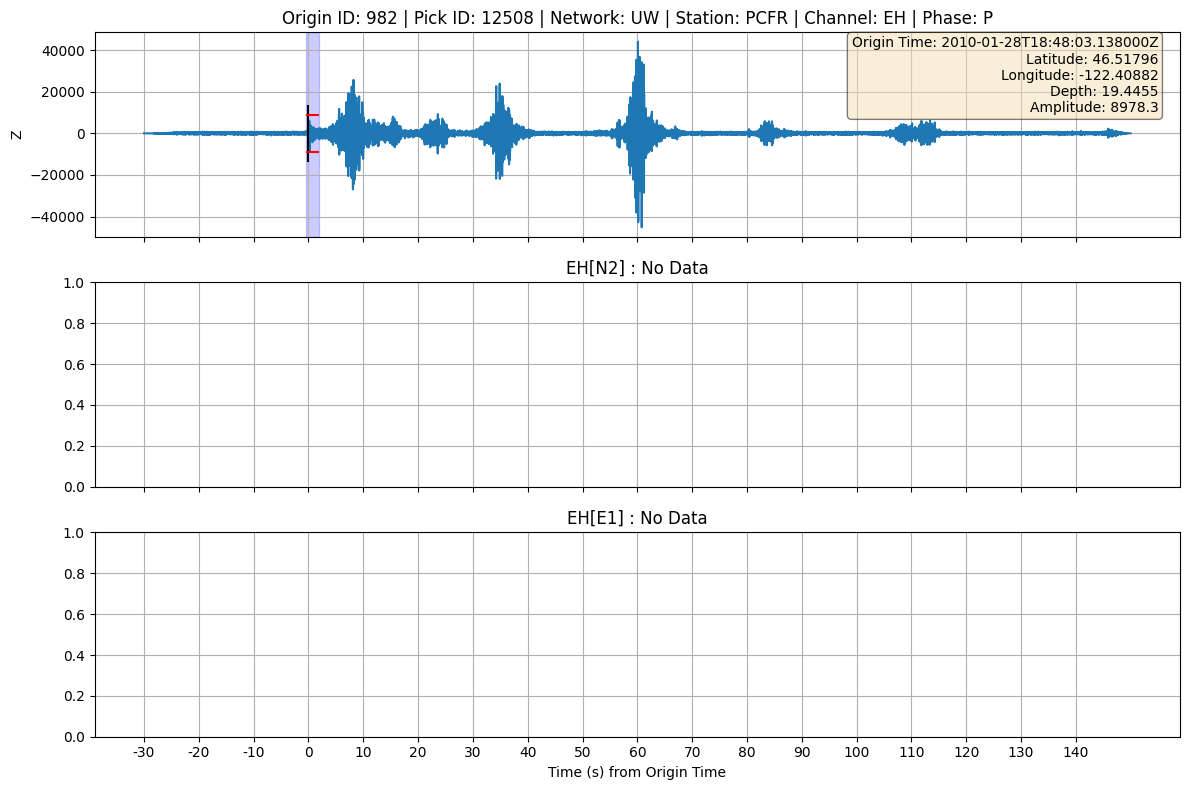

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 645.66200295144
Second print of max_amp 645.66200295144


<Figure size 640x480 with 0 Axes>

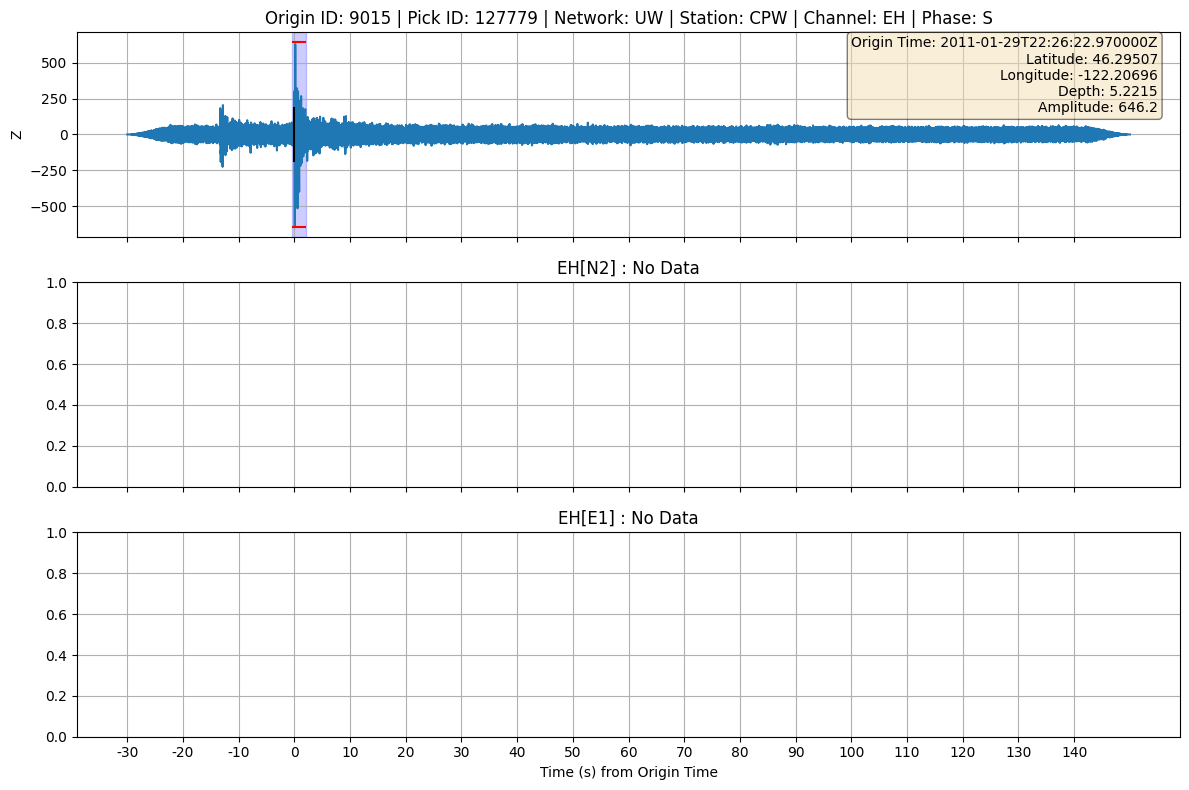

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 1037.52729664499
Second print of max_amp 1037.52729664499
First print of max_amp 1037.52729664499
np.max(np.absolute(tr.data)) 1906.778091046429
Second print of max_amp 1906.778091046429
First print of max_amp 1906.778091046429
np.max(np.absolute(tr.data)) 1033.6396368860326
Second print of max_amp 1906.778091046429


<Figure size 640x480 with 0 Axes>

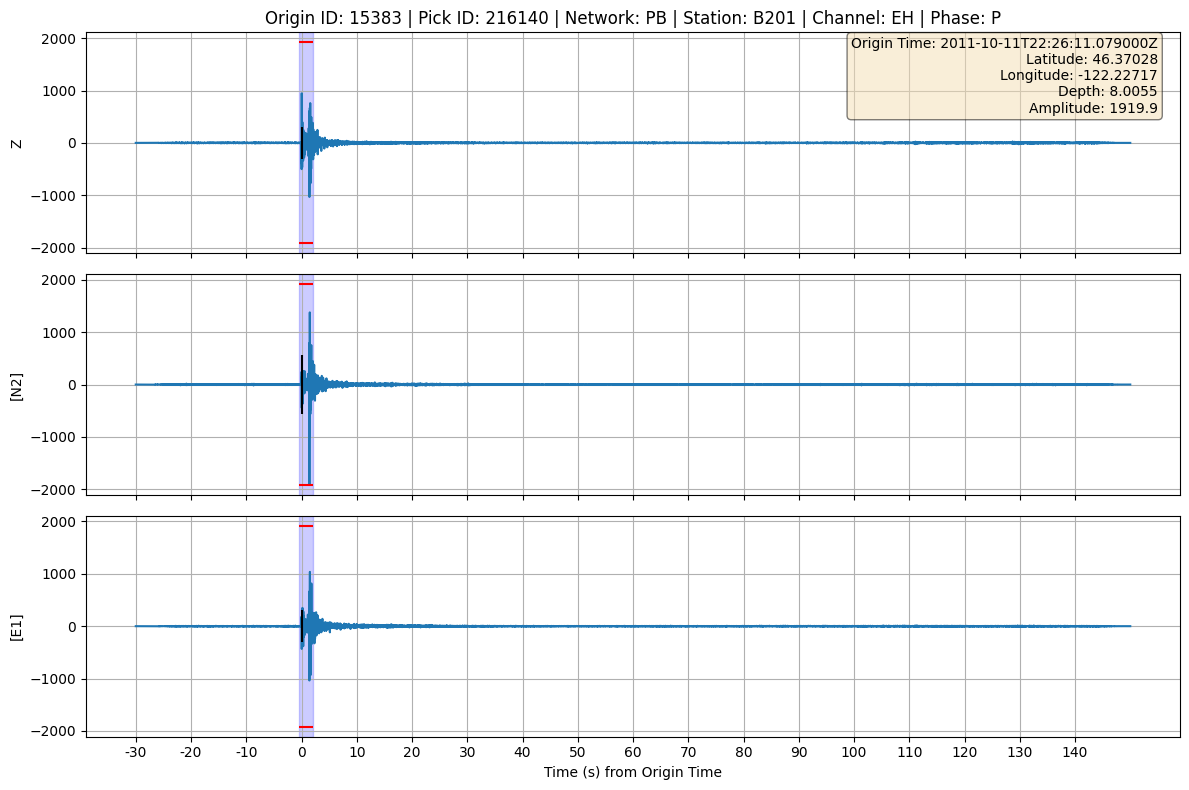

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 34.688063084518944
Second print of max_amp 34.688063084518944
First print of max_amp 34.688063084518944
np.max(np.absolute(tr.data)) 26.480939220215767
Second print of max_amp 34.688063084518944
First print of max_amp 34.688063084518944
np.max(np.absolute(tr.data)) 17.409748435609693
Second print of max_amp 34.688063084518944


<Figure size 640x480 with 0 Axes>

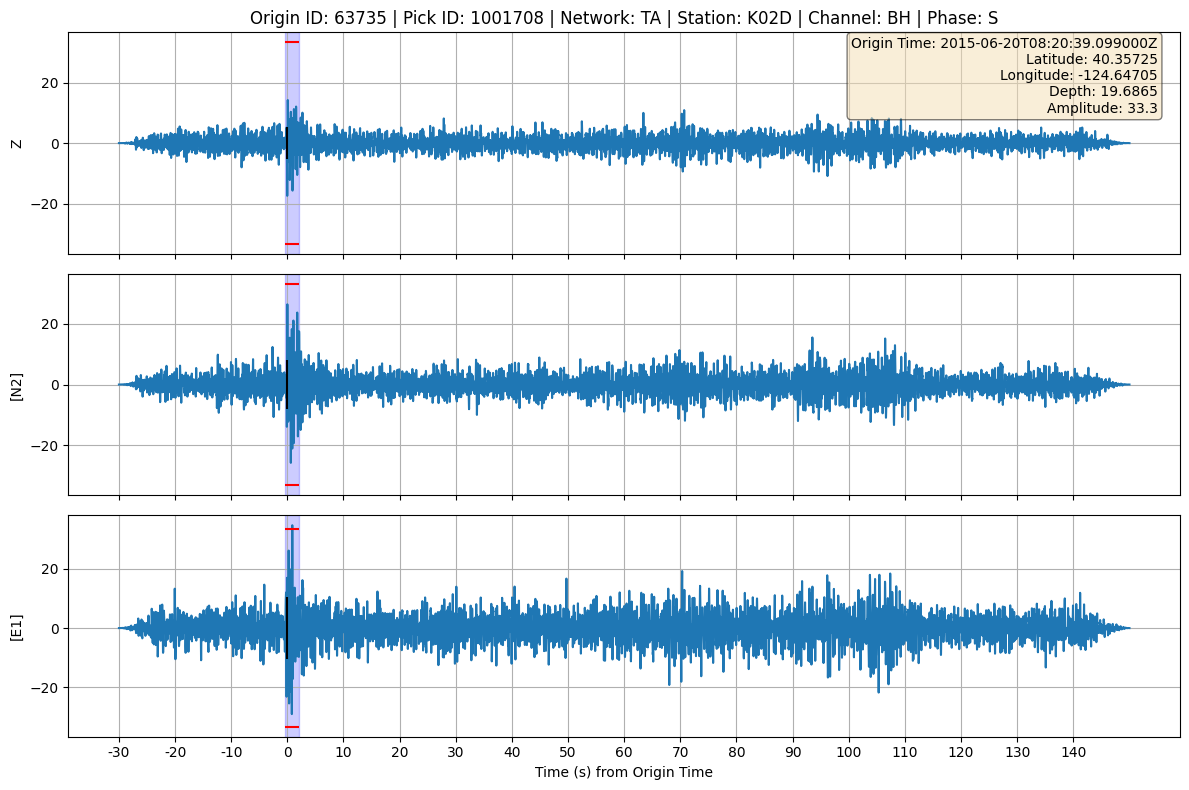

First print of max_amp 0
np.max(np.absolute(tr.data)) 267.0713135182626
Second print of max_amp 267.0713135182626
First print of max_amp 267.0713135182626
np.max(np.absolute(tr.data)) 248.4494700974157
Second print of max_amp 267.0713135182626
First print of max_amp 267.0713135182626
np.max(np.absolute(tr.data)) 295.5009345574216
Second print of max_amp 295.5009345574216


<Figure size 640x480 with 0 Axes>

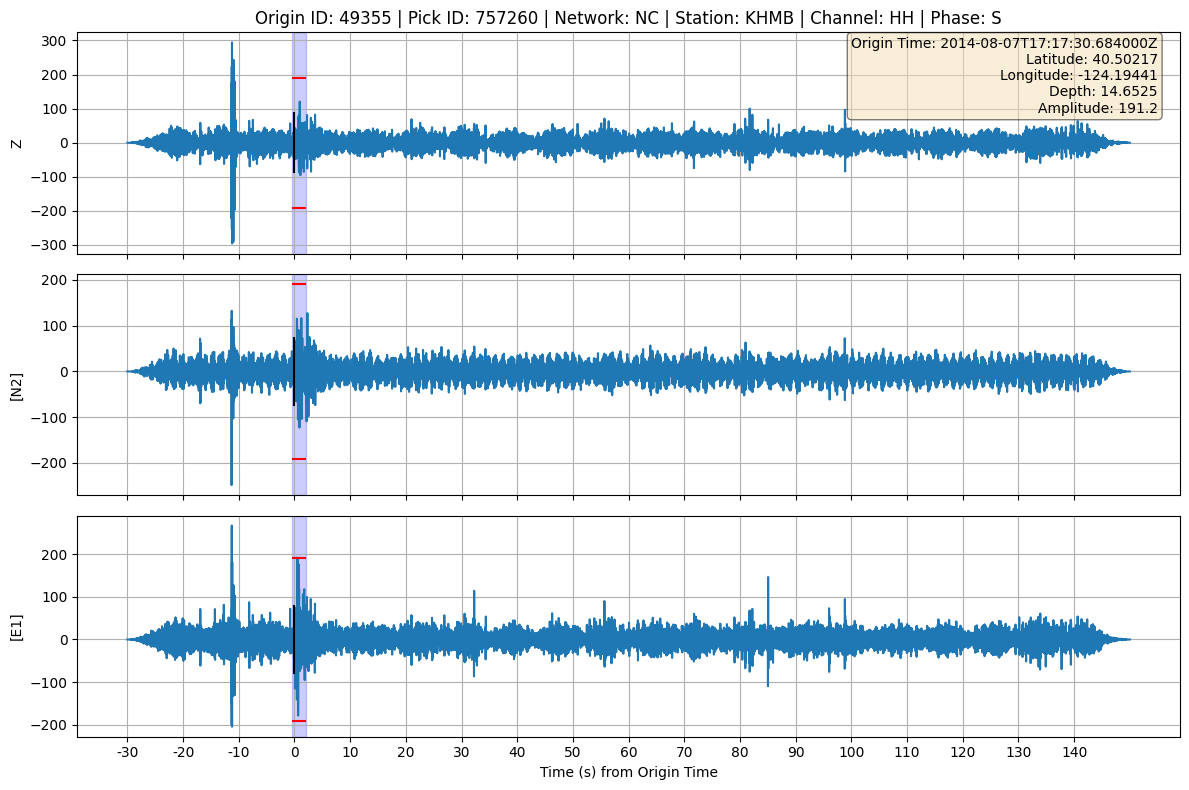

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 127.9350688040054
Second print of max_amp 127.9350688040054
First print of max_amp 127.9350688040054
np.max(np.absolute(tr.data)) 117.51451248602166
Second print of max_amp 127.9350688040054
First print of max_amp 127.9350688040054
np.max(np.absolute(tr.data)) 150.0860816025886
Second print of max_amp 150.0860816025886


<Figure size 640x480 with 0 Axes>

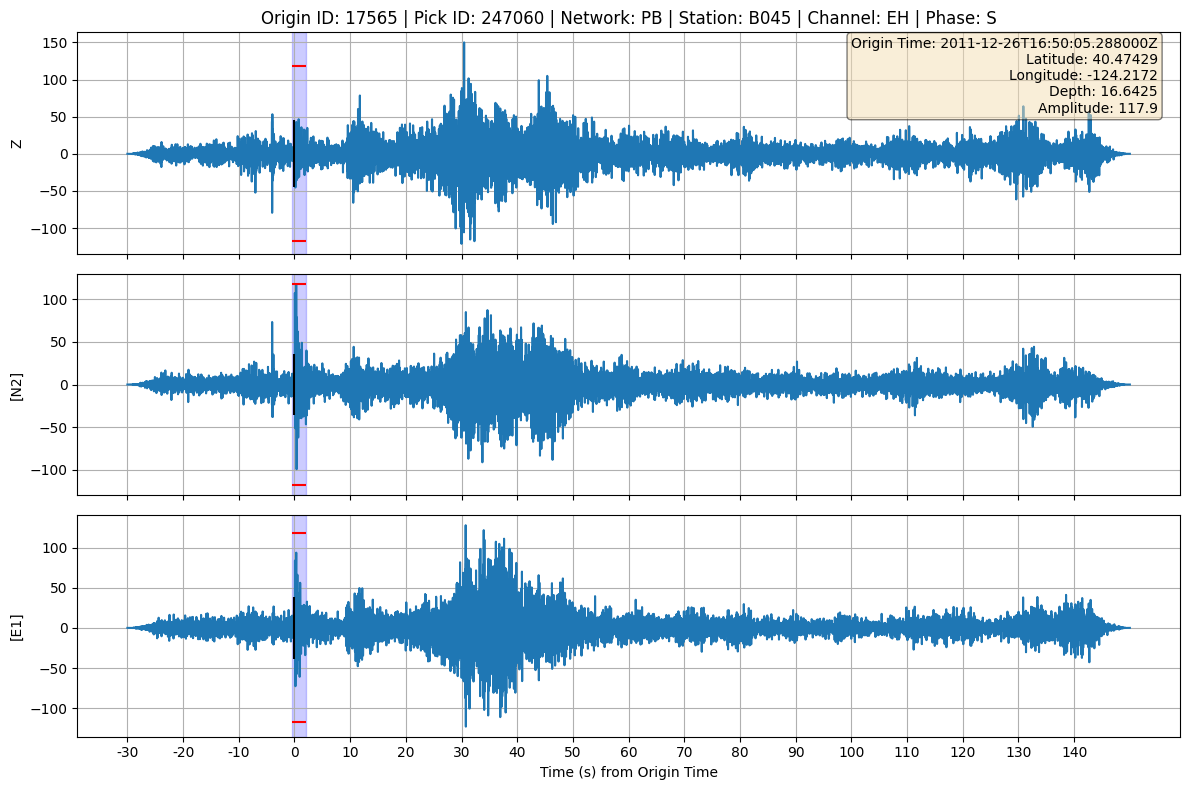

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 61.196878905625724
Second print of max_amp 61.196878905625724
First print of max_amp 61.196878905625724
np.max(np.absolute(tr.data)) 70.1760211739543
Second print of max_amp 70.1760211739543
First print of max_amp 70.1760211739543
np.max(np.absolute(tr.data)) 54.79294833043327
Second print of max_amp 70.1760211739543


<Figure size 640x480 with 0 Axes>

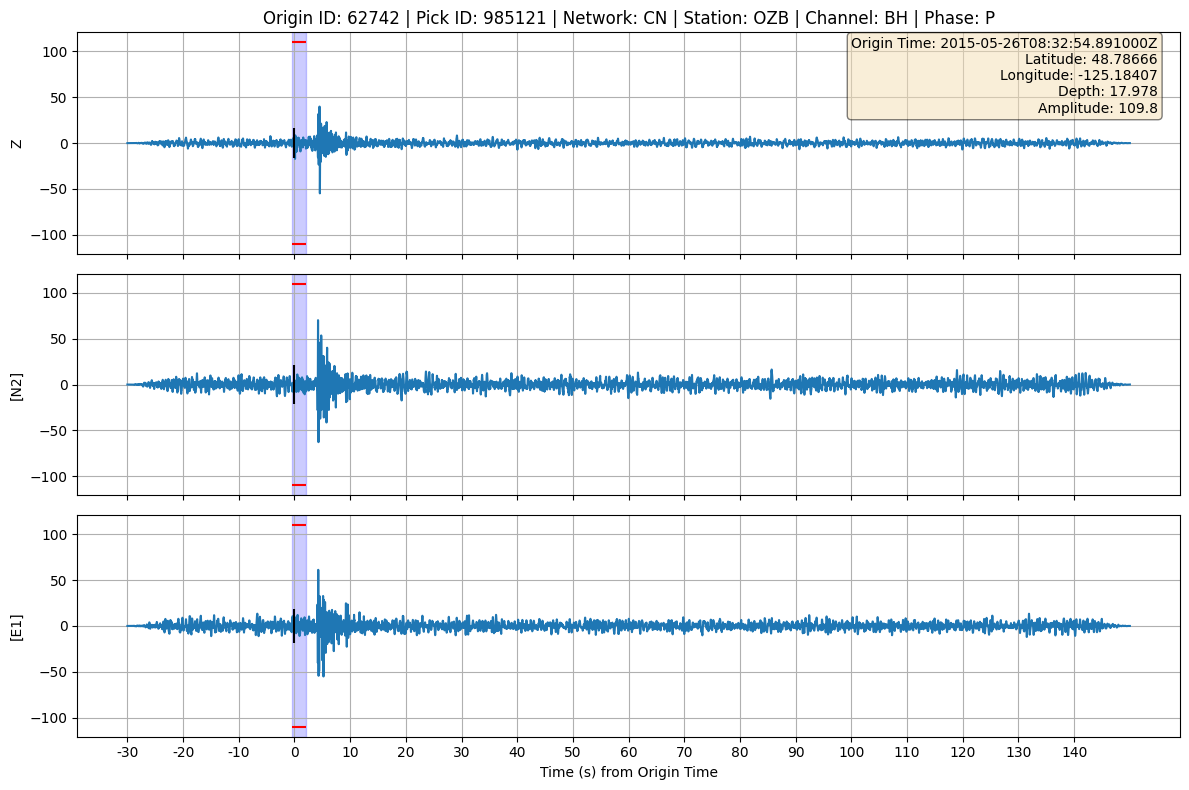

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 73.40633192212901
Second print of max_amp 73.40633192212901
First print of max_amp 73.40633192212901
np.max(np.absolute(tr.data)) 41.740839925283915
Second print of max_amp 73.40633192212901
First print of max_amp 73.40633192212901
np.max(np.absolute(tr.data)) 25.399563182365224
Second print of max_amp 73.40633192212901


<Figure size 640x480 with 0 Axes>

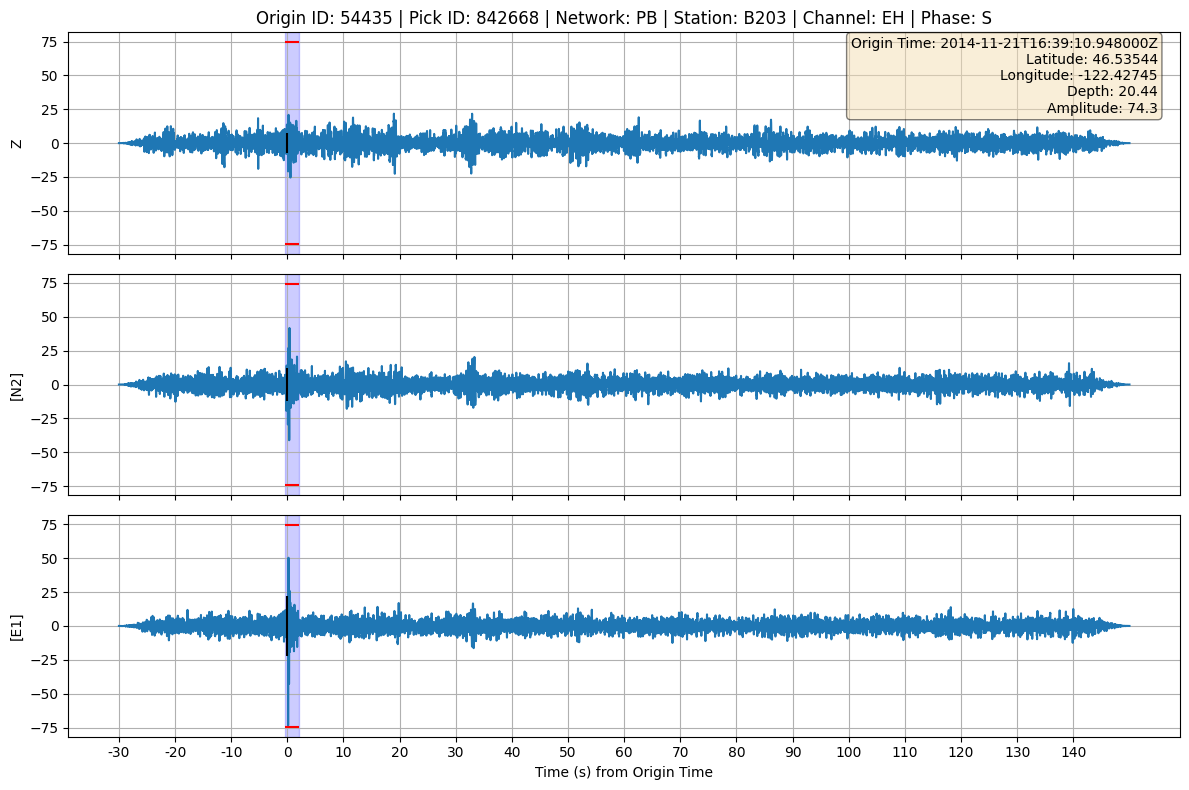

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 93.49956723170106
Second print of max_amp 93.49956723170106


<Figure size 640x480 with 0 Axes>

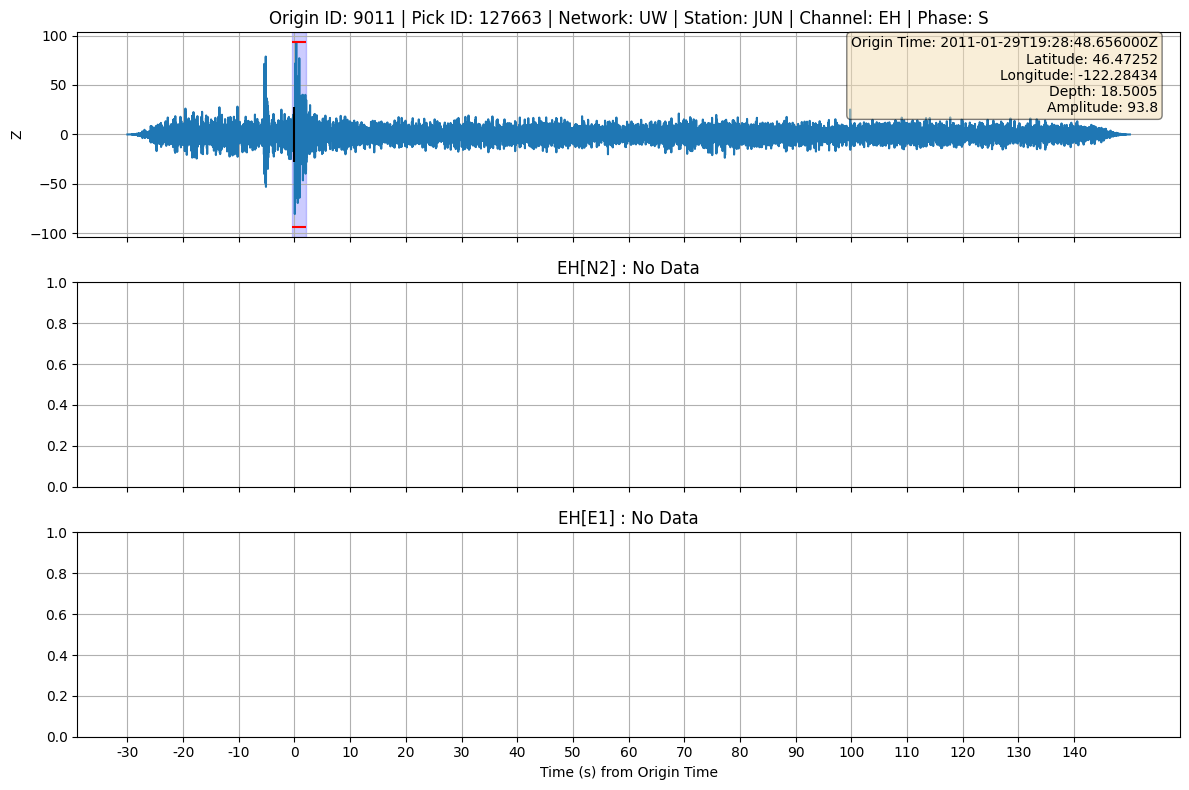

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 192.8507995797525
Second print of max_amp 192.8507995797525
First print of max_amp 192.8507995797525
np.max(np.absolute(tr.data)) 147.53408715362502
Second print of max_amp 192.8507995797525
First print of max_amp 192.8507995797525
np.max(np.absolute(tr.data)) 88.97677322445963
Second print of max_amp 192.8507995797525


<Figure size 640x480 with 0 Axes>

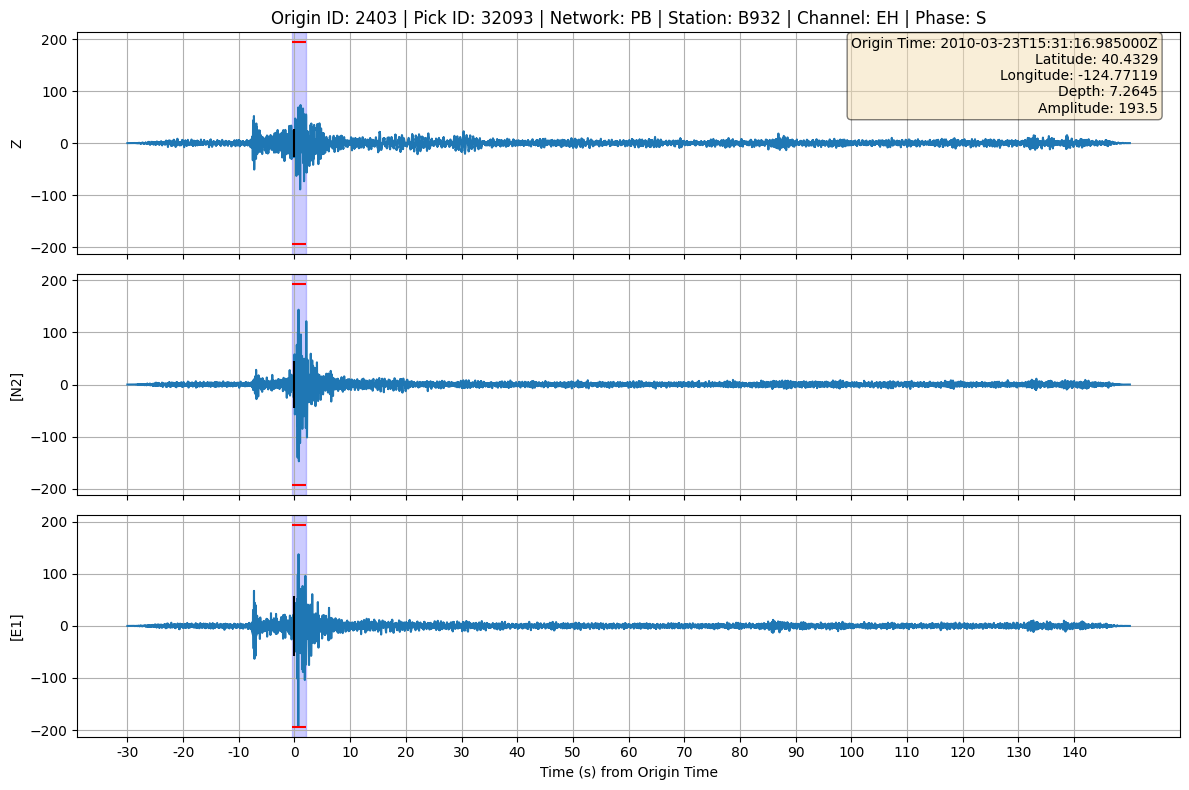

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 438.66873632843937
Second print of max_amp 438.66873632843937


<Figure size 640x480 with 0 Axes>

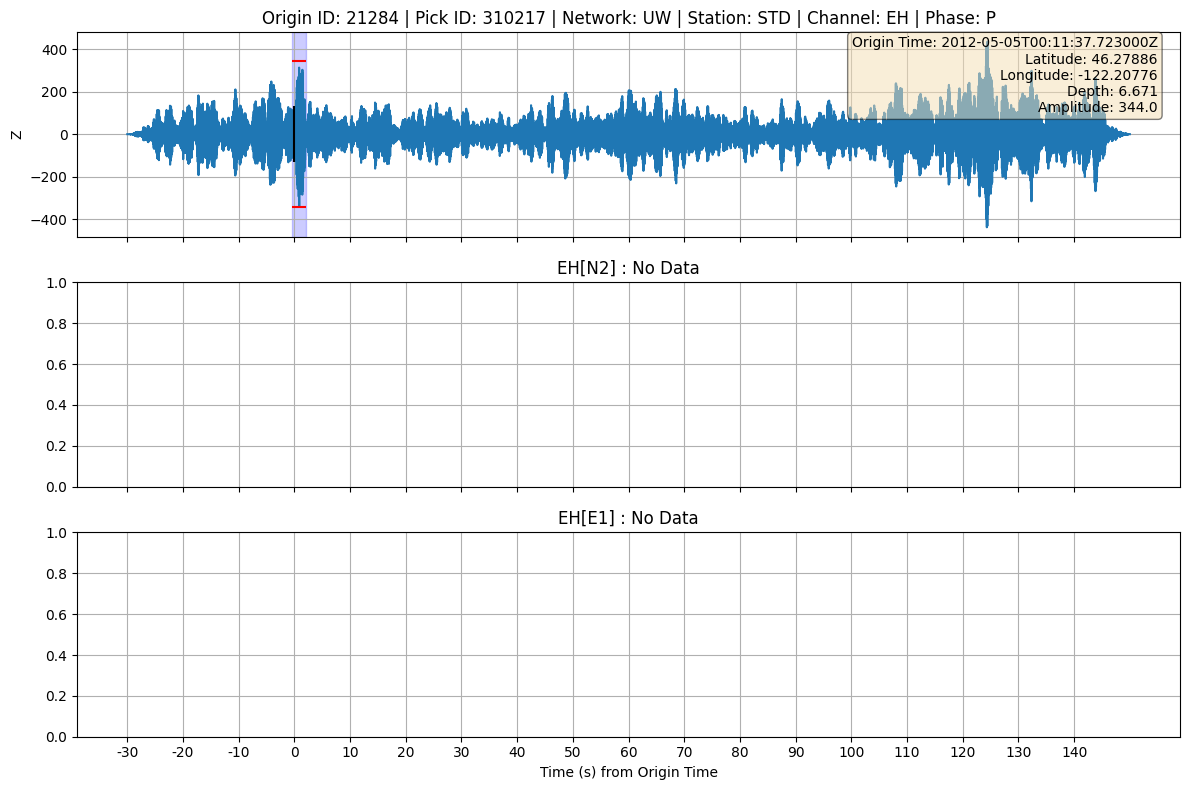

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 78960.38602474675
Second print of max_amp 78960.38602474675
First print of max_amp 78960.38602474675
np.max(np.absolute(tr.data)) 63405.56094654169
Second print of max_amp 78960.38602474675
First print of max_amp 78960.38602474675
np.max(np.absolute(tr.data)) 56362.58622974697
Second print of max_amp 78960.38602474675


<Figure size 640x480 with 0 Axes>

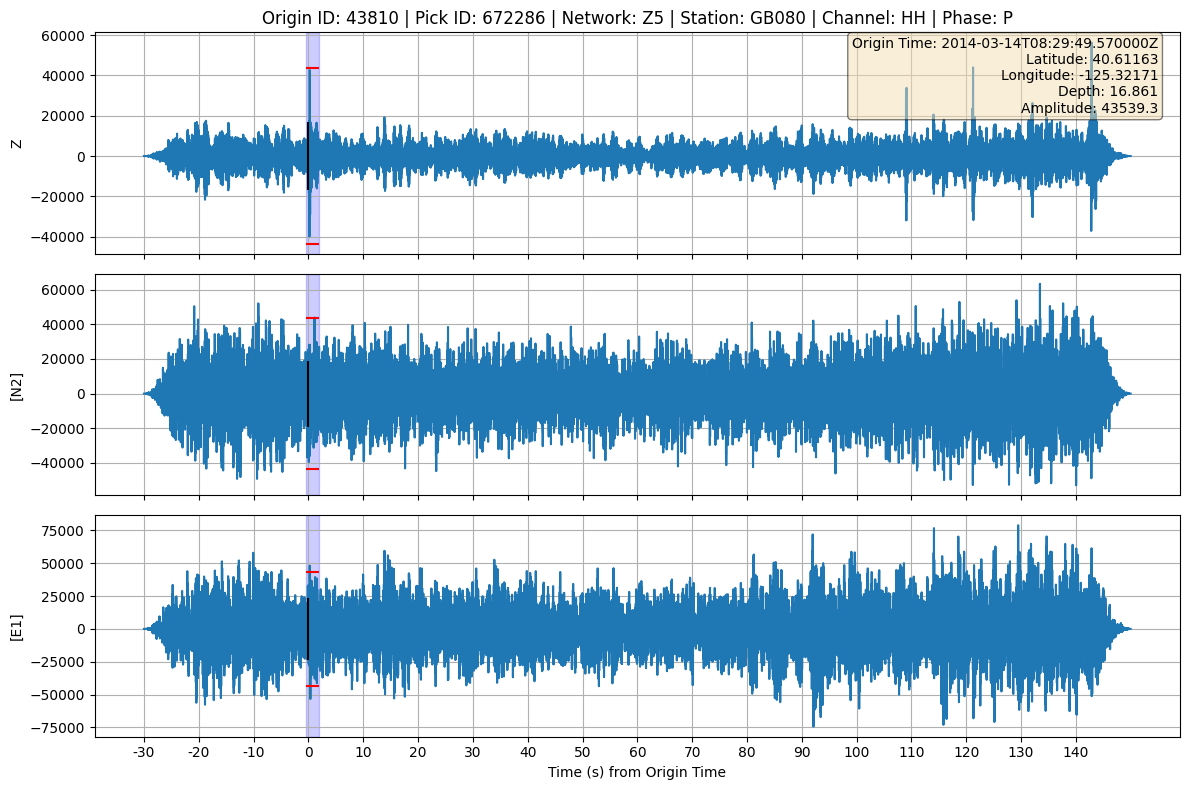

First print of max_amp 0
np.max(np.absolute(tr.data)) 1480.0682311892745
Second print of max_amp 1480.0682311892745
First print of max_amp 1480.0682311892745
np.max(np.absolute(tr.data)) 1374.2009822280338
Second print of max_amp 1480.0682311892745
First print of max_amp 1480.0682311892745
np.max(np.absolute(tr.data)) 588.8726928501474
Second print of max_amp 1480.0682311892745


<Figure size 640x480 with 0 Axes>

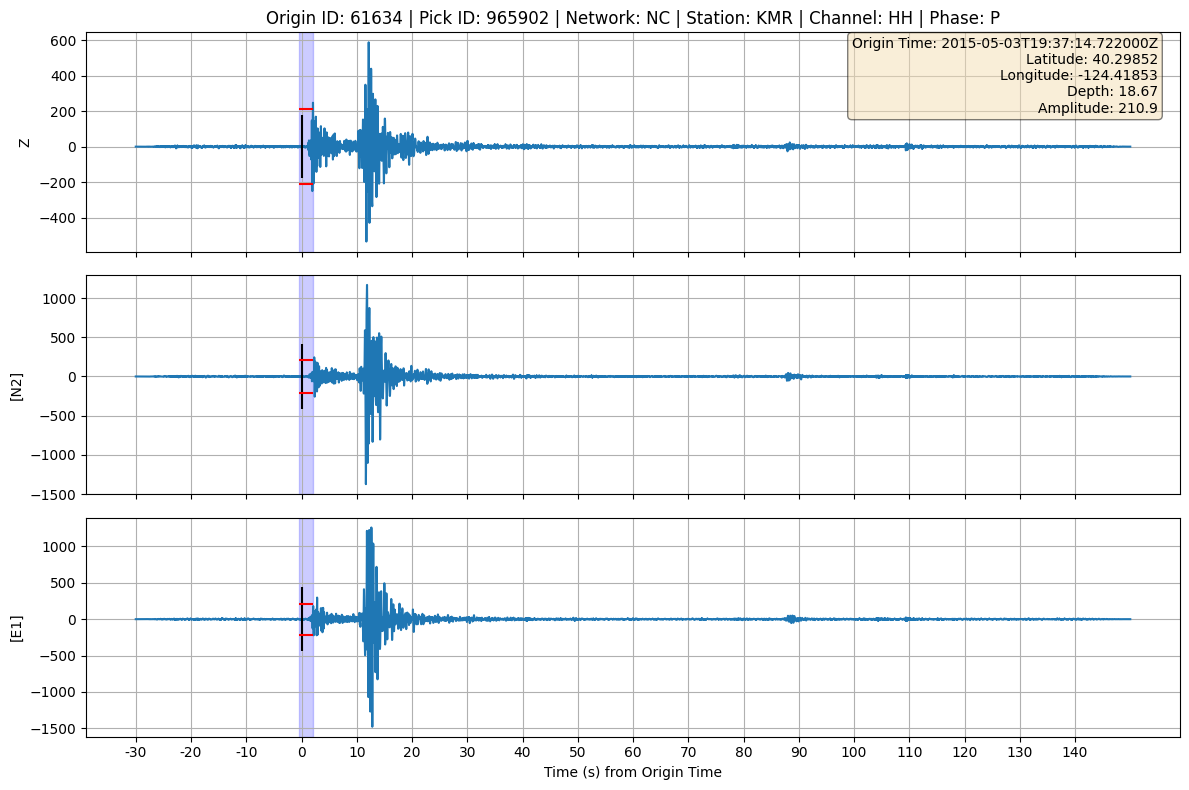

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 309.0398593441053
Second print of max_amp 309.0398593441053
First print of max_amp 309.0398593441053
np.max(np.absolute(tr.data)) 175.99365855531582
Second print of max_amp 309.0398593441053
First print of max_amp 309.0398593441053
np.max(np.absolute(tr.data)) 23.976266736830954
Second print of max_amp 309.0398593441053


<Figure size 640x480 with 0 Axes>

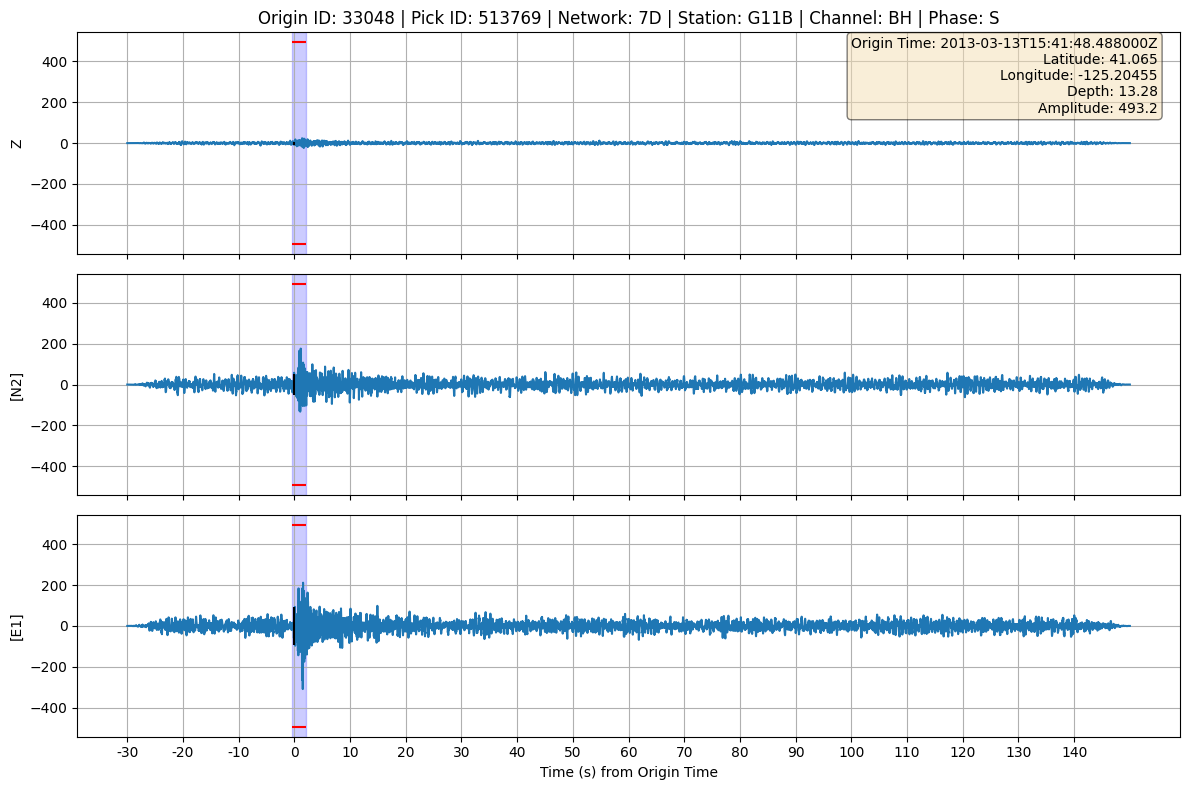

First print of max_amp 0
np.max(np.absolute(tr.data)) 569.4866633809071
Second print of max_amp 569.4866633809071
First print of max_amp 569.4866633809071
np.max(np.absolute(tr.data)) 327.8313484887954
Second print of max_amp 569.4866633809071
First print of max_amp 569.4866633809071
np.max(np.absolute(tr.data)) 115.62167564998778
Second print of max_amp 569.4866633809071


<Figure size 640x480 with 0 Axes>

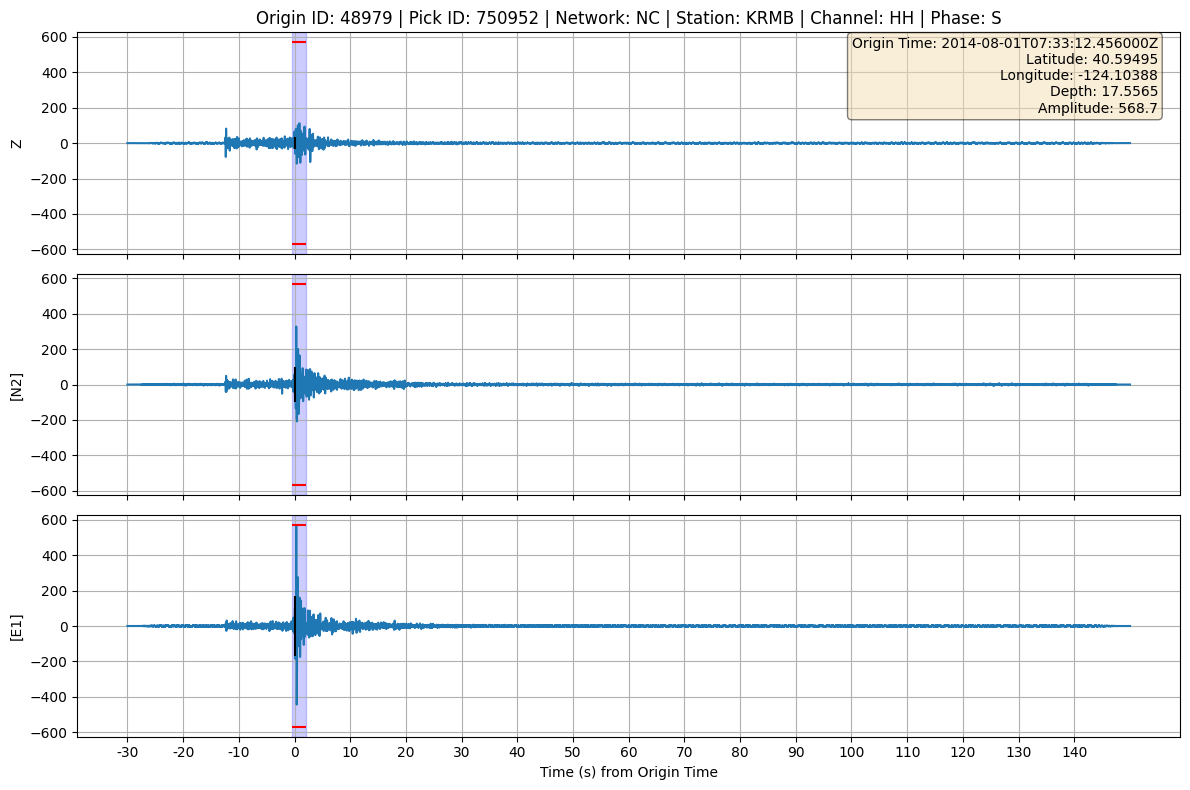

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 3351.7670574310337
Second print of max_amp 3351.7670574310337
First print of max_amp 3351.7670574310337
np.max(np.absolute(tr.data)) 2805.587183966204
Second print of max_amp 3351.7670574310337
First print of max_amp 3351.7670574310337
np.max(np.absolute(tr.data)) 511.5796285532182
Second print of max_amp 3351.7670574310337


<Figure size 640x480 with 0 Axes>

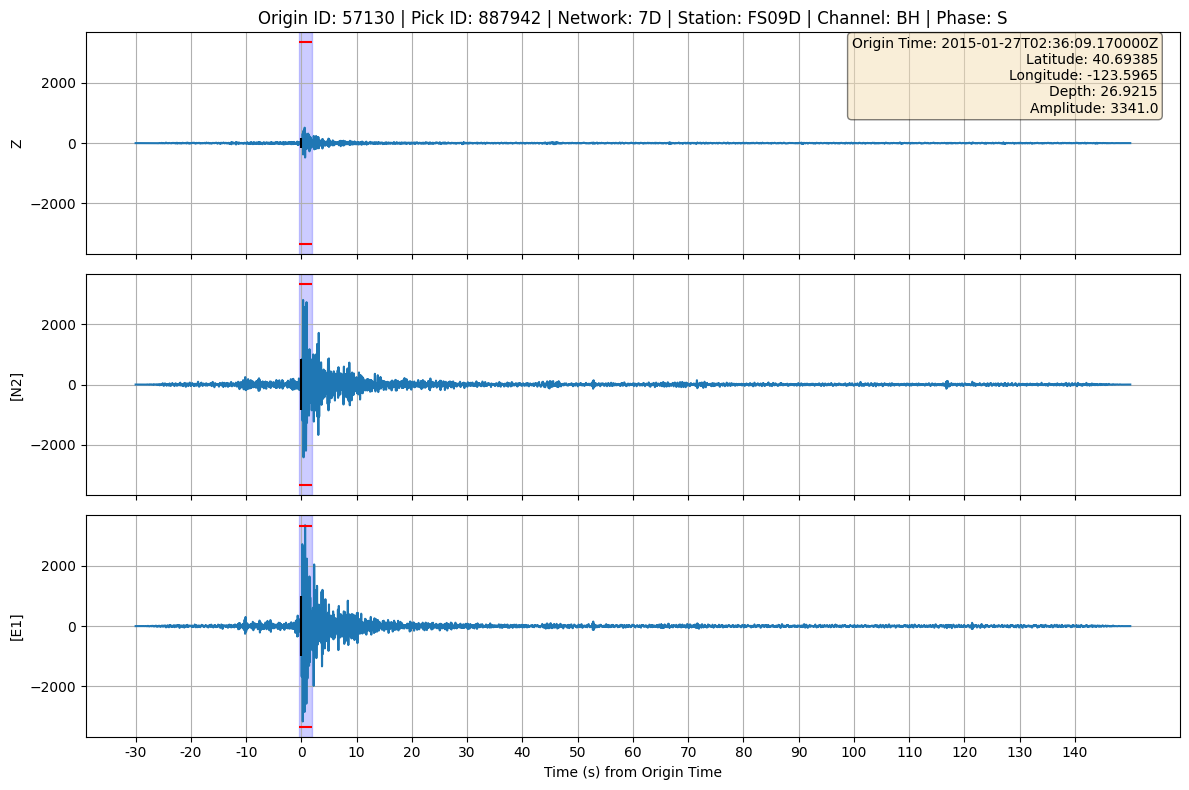

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 2954283.4468665957
Second print of max_amp 2954283.4468665957
First print of max_amp 2954283.4468665957
np.max(np.absolute(tr.data)) 2481056.765553997
Second print of max_amp 2954283.4468665957
First print of max_amp 2954283.4468665957
np.max(np.absolute(tr.data)) 1287319.9537587524
Second print of max_amp 2954283.4468665957


<Figure size 640x480 with 0 Axes>

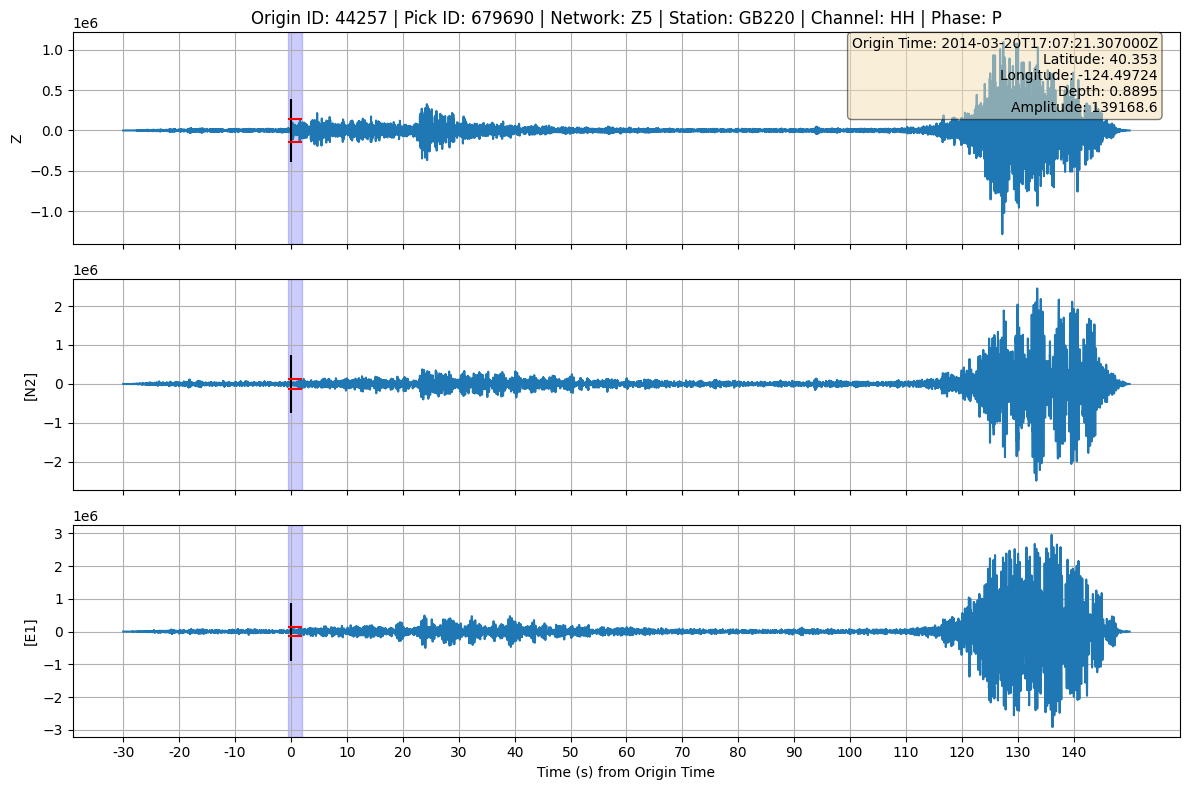

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 189.37382629543055
Second print of max_amp 189.37382629543055
First print of max_amp 189.37382629543055
np.max(np.absolute(tr.data)) 243.58674299316334
Second print of max_amp 243.58674299316334
First print of max_amp 243.58674299316334
np.max(np.absolute(tr.data)) 104.24868031612846
Second print of max_amp 243.58674299316334


<Figure size 640x480 with 0 Axes>

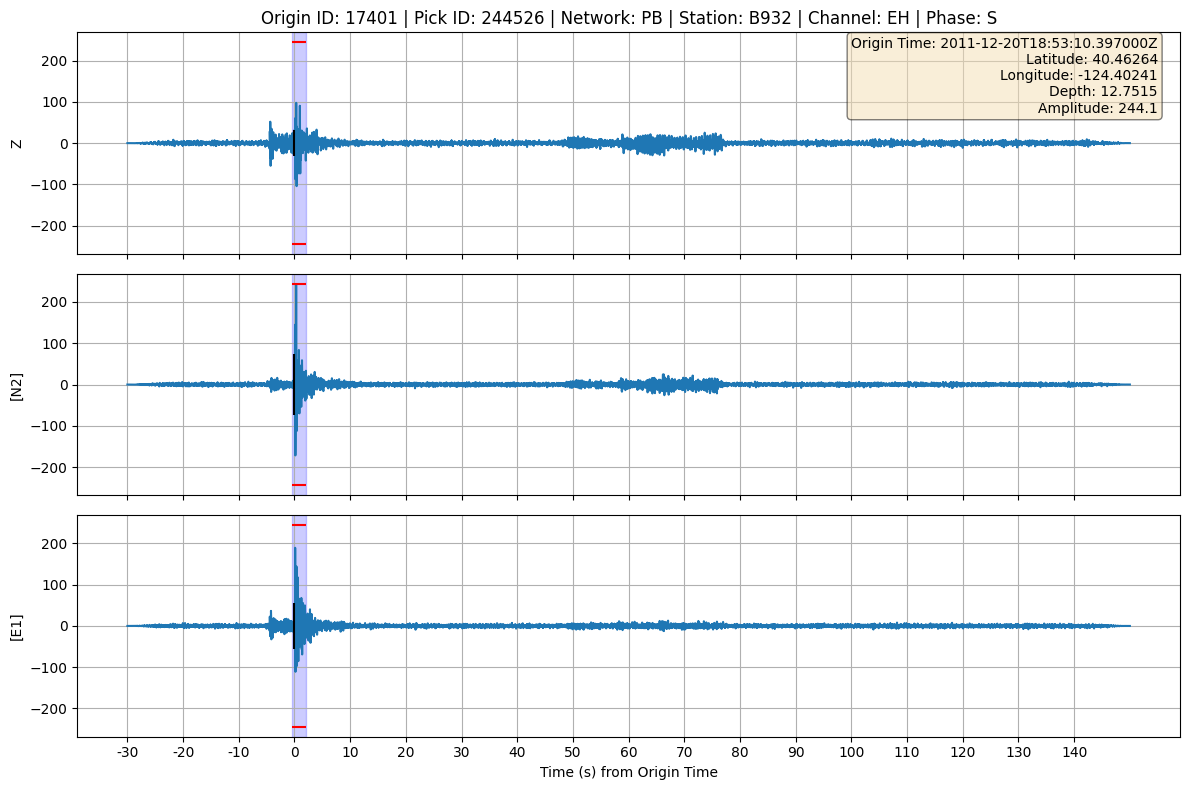

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_waveforms_for_picks(assigned_picks_df, dir_plots, window_before=window_before, window_after=window_after, window_amp_calc_before=window_amp_calc_before, window_amp_calc_after=window_amp_calc_after, n_picks=n_picks, source=source, scaling_factor_vline=scaling_factor_vline)


test

Large window

In [77]:
window_before = 0.5
window_after = 2
source = 'pnwstore'
scaling_factor_vline = 0.3

In [78]:
arid = 63812
pick_info = [] 


In [79]:
orid = assigned_picks_df.iloc[arid]['idx']
pick_id = assigned_picks_df.iloc[arid]['arid']

date, _time = assigned_picks_df.iloc[arid]['time'].split(' ')
datetime_str = date+'T'+_time
origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
latitude = assigned_picks_df.iloc[arid]['latitude']
longitude = assigned_picks_df.iloc[arid]['longitude']
depth = assigned_picks_df.iloc[arid]['depth']

# You may need to adjust these fields to match your DataFrame columns
network = assigned_picks_df.iloc[arid]['station'].split('.')[0].strip()
station = assigned_picks_df.iloc[arid]['station'].split('.')[1].strip()
channel = "*H*"
time_pick = UTCDateTime(assigned_picks_df.iloc[arid]['time_pick'])
time_pick_origin  = UTCDateTime(assigned_picks_df.iloc[arid]['time_pick']) - origin_time
starttime = time_pick - window_before 
endtime = time_pick + window_after
phase = assigned_picks_df.iloc[arid]['phase']
amp = assigned_picks_df.iloc[arid]['Amplitude']

# bulk.append((network, station, channel, starttime, endtime))
pick_info.append({
    'orid': orid,
    'pick_id': pick_id,
    'origin_time': origin_time,
    'latitude': latitude,
    'longitude': longitude,
    'depth': depth,
    'network': network,
    'station': station,
    'channel': channel,
    'starttime': starttime,
    'endtime': endtime,
    'time_pick': time_pick,
    'time_pick_origin': time_pick_origin,
    'phase': phase,
    'amp': amp
})


# Parameters to process waveforms
new_sampling_rate = 100 # in Hz
# freqmax = 15 # in Hz
# freqmin = 4 # in Hz
freq_highpass = 2 # in Hz


In [80]:
network = pick_info[0]['network']
station = pick_info[0]['station']
channel = pick_info[0]['channel']
starttime = pick_info[0]['starttime']
endtime = pick_info[0]['endtime']
amp = pick_info[0]['amp']

time_pick = pick_info[0]['time_pick']
time_pick_origin = pick_info[0]['time_pick_origin']

# fname = dir_plots+f"/{network}_{station}_arid_{info['pick_id']}.png"

time.sleep(0.1)

try:
    st = get_waveforms(
        network=network,
        station=station,
        channel=channel,
        starttime=starttime,
        endtime=endtime,
        source=source
    )
except Exception as e:
    print(f"Request failed: {e}")
    st = Stream()

time.sleep(0.1)

# ---------------------------------------------------------
# Select preferred channel family
# ---------------------------------------------------------

has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

sdata = Stream()

if has_HH:
    sdata += st.select(id=f'{network}.{station}..HH*')
    channel_prefix = "HH"

elif has_BH:
    sdata += st.select(id=f'{network}.{station}..BH*')
    channel_prefix = "BH"

elif has_EH:
    sdata += st.select(id=f'{network}.{station}..EH*')
    channel_prefix = "EH"

else:
    print(f'No HH, BH, or EH data available at {network}.{station} at {time_pick}. Skipping.')
    # continue

#---Debug---#

sdata.resample(new_sampling_rate)

sdata.detrend(type='demean')
sdata.taper(max_percentage=0.05)
sdata.filter(type='highpass', freq=freq_highpass)

max_amp = 0
for tr in sdata:
    print('First print of max_amp',max_amp)
    print('np.max(np.absolute(tr.data))',np.max(np.absolute(tr.data)))
    
    max_amp = max(max_amp, np.absolute(tr.data).max())
    max_amp2 = max(max_amp, abs(tr.data).max())
    
    
    print('Second print of max_amp',max_amp)

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 906.33073526455
Second print of max_amp 906.33073526455


In [81]:
info = pick_info[0]

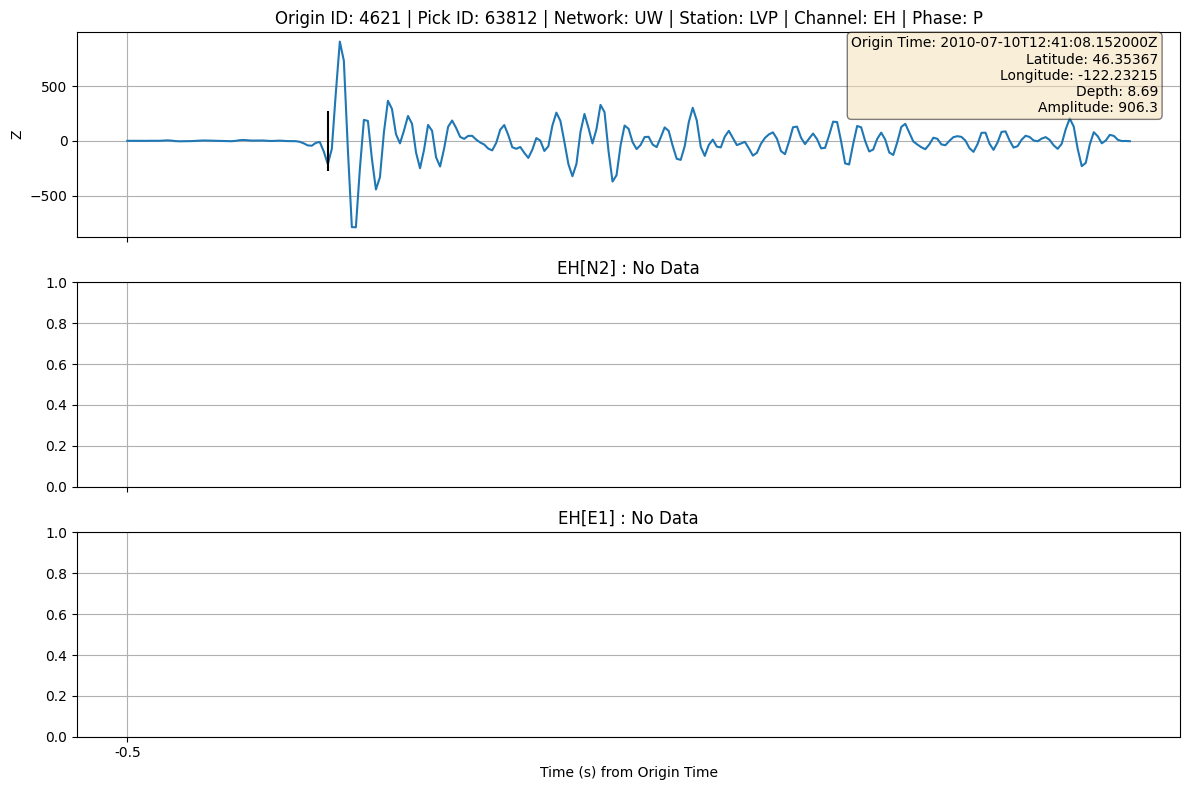

In [82]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 8),
    sharex=True
)

component_list = ['Z', '[N2]', '[E1]']

for ax, comp in zip(axes, component_list):

    tr_select = sdata.select(channel=f"{channel_prefix}{comp}")

    # -----------------------------------------------------
    # Leave blank if component does not exist
    # -----------------------------------------------------

    if len(tr_select) == 0:

        ax.set_title(f"{channel_prefix}{comp} : No Data")
        ax.grid()

        continue

    tr = tr_select[0].copy()

    # -----------------------------------------------------
    # Process waveform
    # -----------------------------------------------------

    data = tr.data

    times = np.linspace(
        -window_before,
        window_after,
        tr.stats.npts
    )

    # print('times', times)
    time_vline = 0

    ymax = np.max(np.abs(data)) * scaling_factor_vline
    ymin = -np.max(np.abs(data)) * scaling_factor_vline

    # xmax = time_vline + window_amp_calc_after
    # xmin = time_vline - window_amp_calc_before

    # -----------------------------------------------------
    # Plot waveform
    # -----------------------------------------------------

    # ax.axvspan(
    #     xmin,
    #     xmax,
    #     color='b',
    #     alpha=0.2
    # )

    ax.plot(times, data)

    ax.vlines(
        time_vline,
        ymin,
        ymax,
        color='k',
        linestyles='solid'
    )

    # ax.hlines(
    #     amp,
    #     xmax=xmax,
    #     xmin=xmin,
    #     color='r'
    # )

    # ax.hlines(
    #     -amp,
    #     xmax=xmax,
    #     xmin=xmin,
    #     color='r'
    # )

    ax.set_ylabel(comp)
    ax.grid()

# ---------------------------------------------------------
# Common formatting
# ---------------------------------------------------------

axes[0].set_title(
    f"Origin ID: {info['orid']} | "
    f"Pick ID: {info['pick_id']} | "
    f"Network: {info['network']} | "
    f"Station: {info['station']} | "
    f"Channel: {channel_prefix} | "
    f"Phase: {info['phase']}"
)

axes[-1].set_xlabel("Time (s) from Origin Time")

ticks = np.arange(-window_before, window_after, 10)
str_ticks = [str(t) for t in ticks]

axes[-1].set_xticks(ticks=ticks, labels=str_ticks)

# Event information box
info_text = (
    f"Origin Time: {info['origin_time']}\n"
    f"Latitude: {info['latitude']}\n"
    f"Longitude: {info['longitude']}\n"
    f"Depth: {info['depth']}\n"
    f"Amplitude: {np.round(amp, decimals=1)}"
)

props = dict(
    boxstyle='round',
    facecolor='wheat',
    alpha=0.5
)

axes[0].text(
    0.98,
    0.98,
    info_text,
    transform=axes[0].transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=props
)

plt.tight_layout()
plt.show()
# plt.savefig(fname=fname, format='png')
plt.close(fig)

time.sleep(0.1)

In [67]:
max_amp2

493.1537290537199

In [68]:
assigned_picks_df.loc[assigned_picks_df['arid']==513769]['Amplitude']

513769    493.153729
Name: Amplitude, dtype: float64

In [69]:
assigned_picks_df.loc[assigned_picks_df['arid']==513769]['Amplitude'].values[0]

493.1537290537199

In [ ]:
# orid = row['idx'].values[0]
# pick_id = row['arid'].values[0]

# date, _time = row['time'].values[0].split(' ')
# datetime_str = date+'T'+_time
# origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
# latitude = row['latitude'].values[0]
# longitude = row['longitude'].values[0]
# depth = row['depth'].values[0]

# # You may need to adjust these fields to match your DataFrame columns
# network = row['station'].values[0].split('.')[0].strip()
# station = row['station'].values[0].split('.')[1].strip()
# channel = "*H*"
# starttime = time_pick - window_before 
# endtime = origin_time + window_after
# time_pick = UTCDateTime(row['time_pick'].values[0])
# time_pick_origin  = UTCDateTime(row['time_pick'].values[0]) - origin_time
# phase = row['phase'].values[0]
# amp = row['Amplitude'].values[0]

# # MOD
# # bulk.append((network, station, channel, starttime, endtime))
# # end MOD 

# pick_info.append({
#     'orid': orid,
#     'pick_id': pick_id,
#     'origin_time': origin_time,
#     'latitude': latitude,
#     'longitude': longitude,
#     'depth': depth,
#     'network': network,
#     'station': station,
#     'channel': channel,
#     'starttime': starttime,
#     'endtime': endtime,
#     'time_pick': time_pick,
#     'time_pick_origin': time_pick_origin,
#     'phase': phase,
#     'amp': amp
# })


# # Parameters to process waveforms
# new_sampling_rate = 100 # in Hz
# # freqmax = 15 # in Hz
# # freqmin = 4 # in Hz
# freq_highpass = 2 # in Hz


In [ ]:
# pick_info_row = pick_info[0]

# network = pick_info_row['network']
# station = pick_info_row['station']
# channel = pick_info_row['channel']
# starttime = pick_info_row['starttime']
# endtime = pick_info_row['endtime']
# amp = pick_info_row['amp']

# time_pick = pick_info_row['time_pick']
# time_pick_origin = pick_info_row['time_pick_origin']

# # MOD
# # fname = dir_plots+f"/{network}_{station}_arid_{info['pick_id']}.png"

# time.sleep(0.1)

# try:
#     st = get_waveforms(
#         network=network,
#         station=station,
#         channel=channel,
#         starttime=starttime,
#         endtime=endtime,
#         source=source
#     )
# except Exception as e:
#     print(f"Request failed: {e}")
#     st = Stream()

# time.sleep(0.1)

# # ---------------------------------------------------------
# # Select preferred channel family
# # ---------------------------------------------------------

# has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
# has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
# has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

# sdata = Stream()

# if has_HH:
#     sdata += st.select(id=f'{network}.{station}..HH*')
#     channel_prefix = "HH"

# elif has_BH:
#     sdata += st.select(id=f'{network}.{station}..BH*')
#     channel_prefix = "BH"

# elif has_EH:
#     sdata += st.select(id=f'{network}.{station}..EH*')
#     channel_prefix = "EH"

# else:
#     print(f'No HH, BH, or EH data available at {network}.{station} at {time_pick}. Skipping.')


# #---Debug---#

# # MOD
# if len(sdata) != 0:
#     sdata.resample(new_sampling_rate)

#     sdata.detrend(type='demean')
#     sdata.taper(max_percentage=0.05)
#     sdata.filter(type='highpass', freq=freq_highpass)

#     max_amp = 0
#     for tr in sdata:
#         print('First print of max_amp',max_amp)
#         print('np.max(np.absolute(tr.data))',np.max(np.absolute(tr.data)))
        
#         max_amp = max(max_amp, np.absolute(tr.data).max())
        
#         print('Second print of max_amp',max_amp)

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 61.196878905625724
Second print of max_amp 61.196878905625724
First print of max_amp 61.196878905625724
np.max(np.absolute(tr.data)) 70.1760211739543
Second print of max_amp 70.1760211739543
First print of max_amp 70.1760211739543
np.max(np.absolute(tr.data)) 54.79294833043327
Second print of max_amp 70.1760211739543


Small window

In [ ]:
# source = 'pnwstore'
# scaling_factor_vline = 0.3
# window_before_calc_amplitude = 0.5
# window_after_calc_amplitude = 2

In [26]:
# arid = 870825

# pick_info = [] 
# row = assigned_picks_df.loc[assigned_picks_df['arid']==arid]
# orid = row['idx'].values[0]
# pick_id = row['arid'].values[0]

# date, _time = row['time'].values[0].split(' ')
# datetime_str = date+'T'+_time
# origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
# latitude = row['latitude'].values[0]
# longitude = row['longitude'].values[0]
# depth = row['depth'].values[0]

# # You may need to adjust these fields to match your DataFrame columns
# network = row['station'].values[0].split('.')[0].strip()
# station = row['station'].values[0].split('.')[1].strip()
# channel = "*H*"
# starttime = origin_time - window_before_calc_amplitude 
# endtime = origin_time + window_after_calc_amplitude
# time_pick = UTCDateTime(row['time_pick'].values[0])
# time_pick_origin  = UTCDateTime(row['time_pick'].values[0]) - origin_time
# phase = row['phase'].values[0]
# amp = row['Amplitude'].values[0]

# # MOD
# # bulk.append((network, station, channel, starttime, endtime))
# # end MOD 

# pick_info.append({
#     'orid': orid,
#     'pick_id': pick_id,
#     'origin_time': origin_time,
#     'latitude': latitude,
#     'longitude': longitude,
#     'depth': depth,
#     'network': network,
#     'station': station,
#     'channel': channel,
#     'starttime': starttime,
#     'endtime': endtime,
#     'time_pick': time_pick,
#     'time_pick_origin': time_pick_origin,
#     'phase': phase,
#     'amp': amp
# })


# # Parameters to process waveforms
# new_sampling_rate = 100 # in Hz
# # freqmax = 15 # in Hz
# # freqmin = 4 # in Hz
# freq_highpass = 2 # in Hz


In [27]:
# pick_info_row = pick_info[0]

# network = pick_info_row['network']
# station = pick_info_row['station']
# channel = pick_info_row['channel']
# starttime = pick_info_row['starttime']
# endtime = pick_info_row['endtime']
# amp = pick_info_row['amp']

# time_pick = pick_info_row['time_pick']
# time_pick_origin = pick_info_row['time_pick_origin']

# # MOD
# # fname = dir_plots+f"/{network}_{station}_arid_{info['pick_id']}.png"

# time.sleep(0.1)

# try:
#     st = get_waveforms(
#         network=network,
#         station=station,
#         channel=channel,
#         starttime=starttime,
#         endtime=endtime,
#         source=source
#     )
# except Exception as e:
#     print(f"Request failed: {e}")
#     st = Stream()

# time.sleep(0.1)

# # ---------------------------------------------------------
# # Select preferred channel family
# # ---------------------------------------------------------

# has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
# has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
# has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

# sdata = Stream()

# if has_HH:
#     sdata += st.select(id=f'{network}.{station}..HH*')
#     channel_prefix = "HH"

# elif has_BH:
#     sdata += st.select(id=f'{network}.{station}..BH*')
#     channel_prefix = "BH"

# elif has_EH:
#     sdata += st.select(id=f'{network}.{station}..EH*')
#     channel_prefix = "EH"

# else:
#     print(f'No HH, BH, or EH data available at {network}.{station} at {time_pick}. Skipping.')


# #---Debug---#

# # MOD
# if len(sdata) != 0:
#     sdata.resample(new_sampling_rate)

#     sdata.detrend(type='demean')
#     sdata.taper(max_percentage=0.05)
#     sdata.filter(type='highpass', freq=freq_highpass)

#     max_amp = 0
#     for tr in sdata:
#         print('First print of max_amp',max_amp)
#         print('np.max(np.absolute(tr.data))',np.max(np.absolute(tr.data)))
        
#         max_amp = max(max_amp, np.absolute(tr.data).max())
        
#         print('Second print of max_amp',max_amp)

First print of max_amp 0
np.max(np.absolute(tr.data)) 68.66065904679301
Second print of max_amp 68.66065904679301
First print of max_amp 68.66065904679301
np.max(np.absolute(tr.data)) 120.59808386908479
Second print of max_amp 120.59808386908479
First print of max_amp 120.59808386908479
np.max(np.absolute(tr.data)) 35.79806550738638
Second print of max_amp 120.59808386908479


Script

In [87]:
source = 'pnwstore'
scaling_factor_vline = 0.3
window_before = 30
window_after = 150
window_before_calc_amplitude = 0.5
window_after_calc_amplitude = 2

freq_highpass = 2 # in Hz
new_sampling_rate = 100 # in Hz

In [92]:
arid = 985121
row = assigned_picks_df.loc[assigned_picks_df['arid']==arid]


# Define the arguments 
date, _time = row['time'].values[0].split(' ')
datetime_str = date+'T'+_time
origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly

time_pick_str = row['time_pick'].values[0]
time_pick = UTCDateTime(time_pick_str)  # Accept ISO string directly

network = row['station'].values[0].split('.')[0].strip()
station = row['station'].values[0].split('.')[1].strip()
channel = '*H*'

# # MOD
starttime = time_pick - window_before 
endtime = time_pick + window_after
# # end MOD

# Inserted
starttime_trim = time_pick - window_before_calc_amplitude 
endtime_trim = time_pick + window_after_calc_amplitude

# # Print the number of items in amplitudes
# print('len(amplitudes)',len(amplitudes))    

# Request a waveform
time.sleep(0.1)

try:
    st = get_waveforms(network=network, station=station, channel=channel,
                        starttime=starttime, endtime=endtime,
                        source=source)
except Exception as e:
    print(f"Request failed: {e}")

    # MOD
    # # Save amplitude to the output DataFrame and CSV on the fly
    # amp = np.nan
    # amplitudes.append(amp)

    # # Save skipped info to CSV
    # skipped_info = {
    #     'network': network,
    #     'station': station,
    #     'channel': channel,
    #     'origin_time': origin_time,
    #     'time_pick': time_pick,
    #     'starttime': starttime,
    #     'endtime': endtime,
    #     'reason': f'Request failed: {e}'
    # }
    # df_skipped = pd.DataFrame([skipped_info])
    # if not os.path.isfile(skipped_csv_path):
    #     df_skipped.to_csv(skipped_csv_path, mode='w', header=True, index=False)
    # else:
    #     df_skipped.to_csv(skipped_csv_path, mode='a', header=False, index=False)
    # end MOD

    # continue
    

# time.sleep(0.1)


# Create a new stream
sdata = Stream()

# Check if loaded data have a vertical component (minimum requirement)
has_Z = bool(st.select(id=f'{network}.{station}..??Z'))
# Check for the presence of HH, BH, and EH channels
has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

if not has_Z:
    e = f'No Vertical Component Data Present at {network}.{station} with HHZ, BHZ or EHZ channels at {time_pick_str}. Skipping'
    print(e)

    # MOD
    # # Save amplitude in the list
    # amp = np.nan
    # amplitudes.append(amp)

    # # Save skipped info to CSV
    # skipped_info = {
    #     'network': network,
    #     'station': station,
    #     'channel': channel,
    #     'origin_time': origin_time,
    #     'time_pick': time_pick,
    #     'starttime': starttime,
    #     'endtime': endtime,
    #     'reason': f'Request failed: {e}'
    # }
    # df_skipped = pd.DataFrame([skipped_info])
    # if not os.path.isfile(skipped_csv_path):
    #     df_skipped.to_csv(skipped_csv_path, mode='w', header=True, index=False)
    # else:
    #     df_skipped.to_csv(skipped_csv_path, mode='a', header=False, index=False)
    # end MOD

    # continue

# Apply selection logic based on channel presence
if has_HH:
    # If all HH, BH, and EH, channels are present, select only HH
    sdata += st.select(id=f'{network}.{station}..HH*')
elif has_BH:
    # If BH and EH channels are present, select only BH
    sdata += st.select(id=f'{network}.{station}..BH*')
elif has_EH:
    # If only EH channels are present, select only EH
    # NTS: This may result in getting only vertical component data - EH? is used for PNSN analog stations
    # NTS: This may also be tricky for pulling full day-volumes because the sampling rate shifts for
    #      analog stations due to the remote digitization scheme used with analog stations
    sdata += st.select(id=f'{network}.{station}..EH*')
else:
    e = f'No data available at {network}.{station} with HHZ, BHZ or EHZ channels at {time_pick_str}. Skipping.'
    print(e)

    # MOD
    # # Save amplitude to the output DataFrame and CSV on the fly
    # amp = np.nan
    # amplitudes.append(amp)

    # # Save skipped info to CSV
    # skipped_info = {
    #     'network': network,
    #     'station': station,
    #     'channel': channel,
    #     'origin_time': origin_time,
    #     'time_pick': time_pick,
    #     'starttime': starttime,
    #     'endtime': endtime,
    #     'reason': f'Request failed: {e}'
    # }
    # df_skipped = pd.DataFrame([skipped_info])
    # if not os.path.isfile(skipped_csv_path):
    #     df_skipped.to_csv(skipped_csv_path, mode='w', header=True, index=False)
    # else:
    #     df_skipped.to_csv(skipped_csv_path, mode='a', header=False, index=False)
    # continue
    # end MOD

# Resample
sdata.resample(new_sampling_rate)
    
# Apply highpass filter
sdata.detrend(type='demean')
sdata.taper(max_percentage=0.05)
sdata.filter(type='highpass', freq=freq_highpass)

trimmed_data = sdata.copy().trim(starttime=starttime_trim, endtime=endtime_trim)

max_amp = 0
for tr in trimmed_data:
    print(trimmed_data)
    print('First print of max_amp',max_amp)
    print('np.max(np.absolute(tr.data))',np.max(np.absolute(tr.data)))
    
    max_amp = max(max_amp, np.absolute(tr.data).max())
    
    print('Second print of max_amp',max_amp)


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


3 Trace(s) in Stream:
CN.OZB..BHE | 2015-05-26T08:32:59.575000Z - 2015-05-26T08:33:02.075000Z | 100.0 Hz, 251 samples
CN.OZB..BHN | 2015-05-26T08:32:59.575000Z - 2015-05-26T08:33:02.075000Z | 100.0 Hz, 251 samples
CN.OZB..BHZ | 2015-05-26T08:32:59.575000Z - 2015-05-26T08:33:02.075000Z | 100.0 Hz, 251 samples
First print of max_amp 0
np.max(np.absolute(tr.data)) 12.01627691436634
Second print of max_amp 12.01627691436634
3 Trace(s) in Stream:
CN.OZB..BHE | 2015-05-26T08:32:59.575000Z - 2015-05-26T08:33:02.075000Z | 100.0 Hz, 251 samples
CN.OZB..BHN | 2015-05-26T08:32:59.575000Z - 2015-05-26T08:33:02.075000Z | 100.0 Hz, 251 samples
CN.OZB..BHZ | 2015-05-26T08:32:59.575000Z - 2015-05-26T08:33:02.075000Z | 100.0 Hz, 251 samples
First print of max_amp 12.01627691436634
np.max(np.absolute(tr.data)) 10.972825714105355
Second print of max_amp 12.01627691436634
3 Trace(s) in Stream:
CN.OZB..BHE | 2015-05-26T08:32:59.575000Z - 2015-05-26T08:33:02.075000Z | 100.0 Hz, 251 samples
CN.OZB..BHN | 201

In [91]:
max_amp

17.204689179140466

end test

backup

In [ ]:
def plot_waveforms_for_picks(window_before=0.5, window_after=2, n_picks=10, source='pnwstore', scaling_factor_vline=0.1):
    #---Copied from calculate_amplitudes.py---#

    # Read the data frame
    datasets_dir =  '/wd1/hbito_data/data/datasets_all_regions'
    # path_assigned_picks_df = f'{datasets_dir}/Cascadia_updated_catalog_picks_assignment_ver_3.csv' MOD

    # Prepare output CSV path
    output_csv_path = f'{datasets_dir}/Cascadia_updated_catalog_picks_assignment_ver_3_w_amp_test.csv'

    # # File to save skipped picks MOD
    # skipped_csv_path = f'{datasets_dir}/calculate_amplitudes_skipped_picks_test.csv'

    assigned_picks_df = pd.read_csv(output_csv_path, index_col=False).copy()

    ##--Inserted--## MOD

    ls_idx = np.random.choice(a=len(assigned_picks_df), size=(n_picks))
    subset_df = assigned_picks_df.iloc[ls_idx]

    ##--End of insertion--##

    # Define the arguments
    window_before = 0.5 # in sec
    window_after = 2 # in sec
    source = 'pnwstore'

    freq_highpass = 2 # in Hz
    new_sampling_rate = 100 # in Hzz

    # Run the loop
    amplitudes = []

    for idx, row in tqdm(subset_df.iterrows(), total=len(assigned_picks_df)):

        # Define the arguments 
        date, _time = row['time'].split(' ')
        datetime_str = date+'T'+_time
        origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly

        time_pick_str = row['time_pick'] 
        time_pick = UTCDateTime(time_pick_str)  # Accept ISO string directly

        network = row['station'].split('.')[0].strip()
        station = row['station'].split('.')[1].strip()
        channel = '*H*'
        starttime = time_pick - window_before 
        endtime = time_pick + window_after
    

        # Print the number of items in amplitudes
        print('len(amplitudes)',len(amplitudes))    

        # Request a waveform
        time.sleep(0.1)

        try:
            st = get_waveforms(network=network, station=station, channel=channel,
                                starttime=starttime, endtime=endtime,
                                source=source)
        except Exception as e:
            print(f"Request failed: {e}")

            # # Save amplitude to the output DataFrame and CSV on the fly MOD
            # amp = np.nan
            # amplitudes.append(amp)

            # # Save skipped info to CSV
            # skipped_info = {
            #     'network': network,
            #     'station': station,
            #     'channel': channel,
            #     'origin_time': origin_time,
            #     'time_pick': time_pick,
            #     'starttime': starttime,
            #     'endtime': endtime,
            #     'reason': f'Request failed: {e}'
            # }
            # df_skipped = pd.DataFrame([skipped_info])
            # if not os.path.isfile(skipped_csv_path):
            #     df_skipped.to_csv(skipped_csv_path, mode='w', header=True, index=False)
            # else:
            #     df_skipped.to_csv(skipped_csv_path, mode='a', header=False, index=False)

            continue
            

        # time.sleep(0.1)


        # Create a new stream
        sdata = Stream()
        
        # Check if loaded data have a vertical component (minimum requirement)
        has_Z = bool(st.select(id=f'{network}.{station}..??Z'))
        # Check for the presence of HH, BH, and EH channels
        has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
        has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
        has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

        if not has_Z:
            e = f'No Vertical Component Data Present at {network}.{station} with the HH, BH or EH channels at {time_pick_str}. Skipping'
            print(e)

            # # Save amplitude in the list MOD
            # amp = np.nan
            # amplitudes.append(amp)

            # # Save skipped info to CSV
            # skipped_info = {
            #     'network': network,
            #     'station': station,
            #     'channel': channel,
            #     'origin_time': origin_time,
            #     'time_pick': time_pick,
            #     'starttime': starttime,
            #     'endtime': endtime,
            #     'reason': f'Request failed: {e}'
            # }
            # df_skipped = pd.DataFrame([skipped_info])
            # if not os.path.isfile(skipped_csv_path):
            #     df_skipped.to_csv(skipped_csv_path, mode='w', header=True, index=False)
            # else:
            #     df_skipped.to_csv(skipped_csv_path, mode='a', header=False, index=False)

            continue

        # Apply selection logic based on channel presence
        if has_HH:
            # If all HH, BH, and EH, channels are present, select only HH
            sdata += st.select(id=f'{network}.{station}..HH*')
            channel_prefix = 'HH'
        elif has_BH:
            # If BH and EH channels are present, select only BH
            sdata += st.select(id=f'{network}.{station}..BH*')
            channel_prefix = 'BH'
        elif has_EH:
            # If only EH channels are present, select only EH
            # NTS: This may result in getting only vertical component data - EH? is used for PNSN analog stations
            # NTS: This may also be tricky for pulling full day-volumes because the sampling rate shifts for
            #      analog stations due to the remote digitization scheme used with analog stations
            sdata += st.select(id=f'{network}.{station}..EH*')
            channel_prefix = 'EH'
        else:
            e = f'No data available at {network}.{station} with HH, BH or EH channels at {time_pick_str}. Skipping.'
            print(e)

            # # Save amplitude to the output DataFrame and CSV on the fly MOD
            # amp = np.nan
            # amplitudes.append(amp)

            # # Save skipped info to CSV
            # skipped_info = {
            #     'network': network,
            #     'station': station,
            #     'channel': channel,
            #     'origin_time': origin_time,
            #     'time_pick': time_pick,
            #     'starttime': starttime,
            #     'endtime': endtime,
            #     'reason': f'Request failed: {e}'
            # }
            # df_skipped = pd.DataFrame([skipped_info])
            # if not os.path.isfile(skipped_csv_path):
            #     df_skipped.to_csv(skipped_csv_path, mode='w', header=True, index=False)
            # else:
            #     df_skipped.to_csv(skipped_csv_path, mode='a', header=False, index=False)
            continue

        # Resample
        sdata.resample(new_sampling_rate)
            
        # Apply highpass filter
        sdata.detrend(type='demean')
        sdata.taper(max_percentage=0.05)
        sdata.filter(type='highpass', freq=freq_highpass)

        print('sdata', sdata)

        max_amp = 0
        for tr in sdata:
            print('type(tr.data)',type(tr.data))
            print('max_amp',max_amp)
            print('np.max(np.absolute(tr.data))',np.max(np.absolute(tr.data)))
            
            max_amp = max(max_amp, np.absolute(tr.data).max())
            
            print('max_amp',max_amp)

        #---The end of the copy from calculate_amplitudes.py---#

        print('The amplitude calculated now: ', max_amp)

        time_pick_origin = time_pick - origin_time

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 8),
            sharex=True
        )

        component_list = ['Z', '[N2]', '[E1]']

        for ax, comp in zip(axes, component_list):

            print('f"{channel_prefix}{comp}"',f"{channel_prefix}{comp}")

            tr_select = sdata.select(channel=f"{channel_prefix}{comp}")

            # -----------------------------------------------------
            # Leave blank if component does not exist
            # -----------------------------------------------------

            if len(tr_select) == 0:

                ax.set_title(f"{channel_prefix}{comp} : No Data")
                ax.grid()

                continue

            tr = tr_select[0].copy()

            # -----------------------------------------------------
            # Process waveform
            # -----------------------------------------------------

            # tr.resample(new_sampling_rate)

            # tr.detrend(type='demean')
            # tr.taper(max_percentage=0.05)
            # tr.filter(type='highpass', freq=freq_highpass)

            data = tr.data

            t_start = - window_before
            t_end = window_after

            times = np.linspace(
                t_start,
                t_end,
                tr.stats.npts
            )

            time_vline = window_before 
            amp = row['Amplitude']

            ymax = np.max(np.abs(data)) * scaling_factor_vline
            ymin = -np.max(np.abs(data)) * scaling_factor_vline

            xmax = t_start
            xmin = t_end

            # ax.axvspan(
            #     xmin,
            #     xmax,
            #     color='b',
            #     alpha=0.2
            # )

            ax.plot(times, data)

            ax.vlines(
                time_vline,
                ymin,
                ymax,
                color='k',
                linestyles='solid',
                label='Pick Time'
            )

            ax.hlines(
                amp,
                xmax=xmax,
                xmin=xmin,
                color='r',
                linestyles='dashed',
                label='Amplitude'
            )

            ax.hlines(
                -amp,
                xmax=xmax,
                xmin=xmin,
                color='r',
                linestyles='dashed'
            )

            ax.set_ylabel(comp)
            ax.grid()

        axes[0].set_title(
            f"Origin ID: {row['idx']} | "
            f"Pick ID: {row['arid']} | "
            f"Network: {network} | "
            f"Station: {station} | "
            f"Channel: {channel_prefix} | "
            f"Phase: {row['phase']}"
        )

        axes[-1].set_xlabel("Time (s) from Origin Time")

        ticks = np.arange(-window_before, window_after, 10)
        str_ticks = [str(t) for t in ticks]

        axes[-1].set_xticks(ticks=ticks, labels=str_ticks)

        # Event information box
        info_text = (
            f"Origin Time: {row['time']}\n"
            f"Latitude: {row['latitude']}\n"
            f"Longitude: {row['longitude']}\n"
            f"Depth: {row['depth']}\n"
            f"Amplitude: {np.round(row['Amplitude'], decimals=1)}"
        )

        props = dict(
            boxstyle='round',
            facecolor='wheat',
            alpha=0.5
        )

        axes[0].text(
            0.98,
            0.98,
            info_text,
            transform=axes[0].transAxes,
            fontsize=10,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=props
        )
    
        dir_plots = datasets_dir+'/plot_examine_amp_calculation'
        fname = dir_plots+f"/{network}_{station}_arid_{row['arid']}.png"
        
        plt.tight_layout()
        plt.show()
        plt.savefig(fname=fname, format='png')
        plt.close(fig)

        time.sleep(0.1)

In [ ]:
# Function to plot waveforms using Obspy bulk request (version of processing the trace)
def plot_waveforms_for_picks(assigned_picks_df, dir_plots, window_before=30, window_after=120, window_amp_calc_before=0.5, window_amp_calc_after=2, n_picks=10, source='pnwstore', scaling_factor_vline=0.1):

    # Prepare the lists
    bulk = []
    pick_info = []
    ls_idx = np.random.choice(a=len(assigned_picks_df), size=(n_picks))
    # ls_idx = np.arange(n_picks)
    
    # for i, row in assigned_picks_df.head(n_picks).iterrows():
    for i in range(len(ls_idx)):
        orid = assigned_picks_df.iloc[ls_idx[i]]['idx']
        pick_id = assigned_picks_df.iloc[ls_idx[i]]['arid']
      
        date, _time = assigned_picks_df.iloc[ls_idx[i]]['time'].split(' ')
        datetime_str = date+'T'+_time
        origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
        latitude = assigned_picks_df.iloc[ls_idx[i]]['latitude']
        longitude = assigned_picks_df.iloc[ls_idx[i]]['longitude']
        depth = assigned_picks_df.iloc[ls_idx[i]]['depth']
        
        # You may need to adjust these fields to match your DataFrame columns
        network = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[0].strip()
        station = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[1].strip()
        channel = "*H*"
        starttime = origin_time - window_before 
        endtime = origin_time + window_after
        time_pick = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick'])
        time_pick_origin  = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick']) - origin_time
        phase = assigned_picks_df.iloc[ls_idx[i]]['phase']
        amp = assigned_picks_df.iloc[ls_idx[i]]['Amplitude']

        bulk.append((network, station, channel, starttime, endtime))
        pick_info.append({
            'orid': orid,
            'pick_id': pick_id,
            'origin_time': origin_time,
            'latitude': latitude,
            'longitude': longitude,
            'depth': depth,
            'network': network,
            'station': station,
            'channel': channel,
            'starttime': starttime,
            'endtime': endtime,
            'time_pick': time_pick,
            'time_pick_origin': time_pick_origin,
            'phase': phase,
            'amp': amp
        })


    # Parameters to process waveforms
    new_sampling_rate = 100 # in Hz
    # freqmax = 15 # in Hz
    # freqmin = 4 # in Hz
    freq_highpass = 2 # in Hz


    # Plotting
    for i, info in enumerate(pick_info):

        network = pick_info[i]['network']
        station = pick_info[i]['station']
        channel = pick_info[i]['channel']
        starttime = pick_info[i]['starttime']
        endtime = pick_info[i]['endtime']
        amp = pick_info[i]['amp']

        time_pick = pick_info[i]['time_pick']
        time_pick_origin = pick_info[i]['time_pick_origin']

        fname = dir_plots+f"/{network}_{station}_arid_{info['pick_id']}.png"

        time.sleep(0.1)

        try:
            st = get_waveforms(
                network=network,
                station=station,
                channel=channel,
                starttime=starttime,
                endtime=endtime,
                source=source
            )
        except Exception as e:
            print(f"Request failed: {e}")
            st = Stream()

        time.sleep(0.1)

        # ---------------------------------------------------------
        # Select preferred channel family
        # ---------------------------------------------------------

        has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
        has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
        has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

        sdata = Stream()

        if has_HH:
            sdata += st.select(id=f'{network}.{station}..HH*')
            channel_prefix = "HH"

        elif has_BH:
            sdata += st.select(id=f'{network}.{station}..BH*')
            channel_prefix = "BH"

        elif has_EH:
            sdata += st.select(id=f'{network}.{station}..EH*')
            channel_prefix = "EH"

        else:
            print(f'No HH, BH, or EH data available at {network}.{station} at {time_pick}. Skipping.')
            continue

        #---Debug---#
        max_amp = 0
        for tr in sdata:
            print('type(tr.data)',type(tr.data))
            print('max_amp',max_amp)
            print('np.max(np.absolute(tr.data))',np.max(np.absolute(tr.data)))
            
            max_amp = max(max_amp, np.absolute(tr.data).max())
            
            print('max_amp',max_amp)

        #---End debug---#

        # ---------------------------------------------------------
        # Create figure with 3 components
        # ---------------------------------------------------------

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 8),
            sharex=True
        )

        component_list = ['Z', '[N2]', '[E1]']

        for ax, comp in zip(axes, component_list):

            tr_select = sdata.select(channel=f"{channel_prefix}{comp}")

            # -----------------------------------------------------
            # Leave blank if component does not exist
            # -----------------------------------------------------

            if len(tr_select) == 0:

                ax.set_title(f"{channel_prefix}{comp} : No Data")
                ax.grid()

                continue

            tr = tr_select[0].copy()

            # -----------------------------------------------------
            # Process waveform
            # -----------------------------------------------------

            tr.resample(new_sampling_rate)

            tr.detrend(type='demean')
            tr.taper(max_percentage=0.05)
            tr.filter(type='highpass', freq=freq_highpass)

            data = tr.data

            times = np.linspace(
                -window_before,
                window_after,
                tr.stats.npts
            )

            time_vline = time_pick_origin

            ymax = np.max(np.abs(data)) * scaling_factor_vline
            ymin = -np.max(np.abs(data)) * scaling_factor_vline

            xmax = time_vline + window_amp_calc_after
            xmin = time_vline - window_amp_calc_before

            # -----------------------------------------------------
            # Plot waveform
            # -----------------------------------------------------

            ax.axvspan(
                xmin,
                xmax,
                color='b',
                alpha=0.2
            )

            ax.plot(times, data)

            ax.vlines(
                time_vline,
                ymin,
                ymax,
                color='k',
                linestyles='solid'
            )

            ax.hlines(
                amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.hlines(
                -amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.set_ylabel(comp)
            ax.grid()

        # ---------------------------------------------------------
        # Common formatting
        # ---------------------------------------------------------

        axes[0].set_title(
            f"Origin ID: {info['orid']} | "
            f"Pick ID: {info['pick_id']} | "
            f"Network: {info['network']} | "
            f"Station: {info['station']} | "
            f"Channel: {channel_prefix} | "
            f"Phase: {info['phase']}"
        )

        axes[-1].set_xlabel("Time (s) from Origin Time")

        ticks = np.arange(-window_before, window_after, 10)
        str_ticks = [str(t) for t in ticks]

        axes[-1].set_xticks(ticks=ticks, labels=str_ticks)

        # Event information box
        info_text = (
            f"Origin Time: {info['origin_time']}\n"
            f"Latitude: {info['latitude']}\n"
            f"Longitude: {info['longitude']}\n"
            f"Depth: {info['depth']}\n"
            f"Amplitude: {np.round(amp, decimals=1)}"
        )

        props = dict(
            boxstyle='round',
            facecolor='wheat',
            alpha=0.5
        )

        axes[0].text(
            0.98,
            0.98,
            info_text,
            transform=axes[0].transAxes,
            fontsize=10,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=props
        )

        plt.tight_layout()
        plt.show()
        plt.savefig(fname=fname, format='png')
        plt.close(fig)

        time.sleep(0.1)



In [ ]:
# Function to plot waveforms using Obspy bulk request
 
def plot_waveforms_for_picks(assigned_picks_df, dir_plots, window_before=30, window_after=120, window_amp_calc_before = 0.5, window_amp_calc_after = 2, n_picks=100, source='pnwstore', scaling_factor_vline=0.1):
     
    # Prepare the lists
    bulk = []
    pick_info = []
    # ls_idx = np.random.choice(a=len(assigned_picks_df), size=(n_picks))
    ls_idx = np.arange(n_picks)
    
    # for i, row in assigned_picks_df.head(n_picks).iterrows():
    for i in range(len(ls_idx)):
        orid = assigned_picks_df.iloc[ls_idx[i]]['idx']
        pick_id = assigned_picks_df.iloc[ls_idx[i]]['arid']
      
        date, _time = assigned_picks_df.iloc[ls_idx[i]]['time'].split(' ')
        datetime_str = date+'T'+_time
        origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
        latitude = assigned_picks_df.iloc[ls_idx[i]]['latitude']
        longitude = assigned_picks_df.iloc[ls_idx[i]]['longitude']
        depth = assigned_picks_df.iloc[ls_idx[i]]['depth']
        
        # You may need to adjust these fields to match your DataFrame columns
        network = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[0].strip()
        station = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[1].strip()
        channel = "*H*"
        starttime = origin_time - window_before 
        endtime = origin_time + window_after
        time_pick = assigned_picks_df.iloc[ls_idx[i]]['time_pick']
        time_pick_origin  = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick']) - origin_time
        phase = assigned_picks_df.iloc[ls_idx[i]]['phase']
        amp = assigned_picks_df.iloc[ls_idx[i]]['Amplitude']

        bulk.append((network, station, channel, starttime, endtime))
        pick_info.append({
            'orid': orid,
            'pick_id': pick_id,
            'origin_time': origin_time,
            'latitude': latitude,
            'longitude': longitude,
            'depth': depth,
            'network': network,
            'station': station,
            'channel': channel,
            'starttime': starttime,
            'endtime': endtime,
            'time_pick': time_pick,
            'time_pick_origin': time_pick_origin,
            'phase': phase,
            'amp': amp
        })


    # Parameters to process waveforms
    new_sampling_rate = 100 # in Hz
    # freqmax = 15 # in Hz
    # freqmin = 4 # in Hz
    freq_highpass = 2 # in Hz


    # Plotting
    for i, info in enumerate(pick_info):

        network = pick_info[i]['network']
        station = pick_info[i]['station']
        channel = pick_info[i]['channel']
        starttime = pick_info[i]['starttime']
        endtime = pick_info[i]['endtime']
        amp = pick_info[i]['amp']

        time_pick = pick_info[i]['time_pick']
        time_pick_origin = pick_info[i]['time_pick_origin']

        fname = dir_plots+f"/{network}_{station}_arid_{info['pick_id']}.png"

        time.sleep(0.1)

        try:
            st = get_waveforms(
                network=network,
                station=station,
                channel=channel,
                starttime=starttime,
                endtime=endtime,
                source=source
            )
        except Exception as e:
            print(f"Request failed: {e}")
            st = Stream()

        time.sleep(0.1)

        # ---------------------------------------------------------
        # Select preferred channel family
        # ---------------------------------------------------------

        has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
        has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
        has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

        sdata = Stream()

        if has_HH:
            sdata += st.select(id=f'{network}.{station}..HH*')
            channel_prefix = "HH"

        elif has_BH:
            sdata += st.select(id=f'{network}.{station}..BH*')
            channel_prefix = "BH"

        elif has_EH:
            sdata += st.select(id=f'{network}.{station}..EH*')
            channel_prefix = "EH"

        else:
            print(f'No HH, BH, or EH data available at {network}.{station} at {time_pick}. Skipping.')
            continue

        # ---------------------------------------------------------
        # Create figure with 3 components
        # ---------------------------------------------------------

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 8),
            sharex=True
        )

        component_list = ['Z', 'N', 'E']

        for ax, comp in zip(axes, component_list):

            tr_select = sdata.select(channel=f"{channel_prefix}{comp}")

            # -----------------------------------------------------
            # Leave blank if component does not exist
            # -----------------------------------------------------

            if len(tr_select) == 0:

                ax.set_title(f"{channel_prefix}{comp} : No Data")
                ax.grid()

                continue

            tr = tr_select[0].copy()

            # -----------------------------------------------------
            # Process waveform
            # -----------------------------------------------------

            tr.resample(new_sampling_rate)

            tr.detrend(type='demean')
            tr.taper(max_percentage=0.05)
            tr.filter(type='highpass', freq=freq_highpass)

            data = tr.data

            times = np.linspace(
                -window_before,
                window_after,
                tr.stats.npts
            )

            time_vline = time_pick_origin

            ymax = np.max(np.abs(data)) * scaling_factor_vline
            ymin = -np.max(np.abs(data)) * scaling_factor_vline

            xmax = time_vline + window_amp_calc_after
            xmin = time_vline - window_amp_calc_before

            # -----------------------------------------------------
            # Plot waveform
            # -----------------------------------------------------

            ax.axvspan(
                xmin,
                xmax,
                color='b',
                alpha=0.2
            )

            ax.plot(times, data)

            ax.vlines(
                time_vline,
                ymin,
                ymax,
                color='k',
                linestyles='solid'
            )

            ax.hlines(
                amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.hlines(
                -amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.set_ylabel(comp)
            ax.grid()

        # ---------------------------------------------------------
        # Common formatting
        # ---------------------------------------------------------

        axes[0].set_title(
            f"Origin ID: {info['orid']} | "
            f"Pick ID: {info['pick_id']} | "
            f"Network: {info['network']} | "
            f"Station: {info['station']} | "
            f"Channel: {channel_prefix} | "
            f"Phase: {info['phase']}"
        )

        axes[-1].set_xlabel("Time (s) from Origin Time")

        ticks = np.arange(-window_before, window_after, 10)
        str_ticks = [str(t) for t in ticks]

        axes[-1].set_xticks(ticks=ticks, labels=str_ticks)

        # Event information box
        info_text = (
            f"Origin Time: {info['origin_time']}\n"
            f"Latitude: {info['latitude']}\n"
            f"Longitude: {info['longitude']}\n"
            f"Depth: {info['depth']}\n"
            f"Amplitude: {np.round(amp, decimals=1)}"
        )

        props = dict(
            boxstyle='round',
            facecolor='wheat',
            alpha=0.5
        )

        axes[0].text(
            0.98,
            0.98,
            info_text,
            transform=axes[0].transAxes,
            fontsize=10,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=props
        )

        plt.tight_layout()
        plt.show()
        plt.savefig(fname=fname, format='png')
        plt.close(fig)

        time.sleep(0.1)



In [ ]:
# Function to plot waveforms using Obspy bulk request
 
def plot_waveforms_for_picks(assigned_picks_df, dir_plots, window_before=30, window_after=120, n_picks=10, source='pnwstore', scaling_factor_vline=0.1):
     
    # Prepare the lists
    bulk = []
    pick_info = []
    ls_idx = np.random.choice(a=len(assigned_picks_df), size=(n_picks))
    subset_df = 
    # ls_idx = np.arange(n_picks)
    
    # for i, row in assigned_picks_df.head(n_picks).iterrows():
    for i in range(len(ls_idx)):
        orid = assigned_picks_df.iloc[ls_idx[i]]['idx']
        pick_id = assigned_picks_df.iloc[ls_idx[i]]['arid']
      
        date, _time = assigned_picks_df.iloc[ls_idx[i]]['time'].split(' ')
        datetime_str = date+'T'+_time
        origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
        latitude = assigned_picks_df.iloc[ls_idx[i]]['latitude']
        longitude = assigned_picks_df.iloc[ls_idx[i]]['longitude']
        depth = assigned_picks_df.iloc[ls_idx[i]]['depth']
        
        # You may need to adjust these fields to match your DataFrame columns
        network = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[0].strip()
        station = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[1].strip()
        channel = "*H*"
        starttime = origin_time - window_before 
        endtime = origin_time + window_after
        time_pick = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick'])
        time_pick_origin  = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick']) - origin_time
        phase = assigned_picks_df.iloc[ls_idx[i]]['phase']
        amp = assigned_picks_df.iloc[ls_idx[i]]['Amplitude']

        bulk.append((network, station, channel, starttime, endtime))
        pick_info.append({
            'orid': orid,
            'pick_id': pick_id,
            'origin_time': origin_time,
            'latitude': latitude,
            'longitude': longitude,
            'depth': depth,
            'network': network,
            'station': station,
            'channel': channel,
            'starttime': starttime,
            'endtime': endtime,
            'time_pick': time_pick,
            'time_pick_origin': time_pick_origin,
            'phase': phase,
            'amp': amp
        })


    # Parameters to process waveforms
    new_sampling_rate = 100 # in Hz
    # freqmax = 15 # in Hz
    # freqmin = 4 # in Hz
    freq_highpass = 2 # in Hz


    # Plotting
    for i, info in enumerate(pick_info):

        network = pick_info[i]['network']
        station = pick_info[i]['station']
        channel = pick_info[i]['channel']
        starttime = pick_info[i]['starttime']
        endtime = pick_info[i]['endtime']
        amp = pick_info[i]['amp']

        time_pick = pick_info[i]['time_pick']
        time_pick_origin = pick_info[i]['time_pick_origin']

        fname = dir_plots+f"/{network}_{station}_arid_{info['pick_id']}.png"

        time.sleep(0.1)

        try:
            st = get_waveforms(
                network=network,
                station=station,
                channel=channel,
                starttime=starttime,
                endtime=endtime,
                source=source
            )
        except Exception as e:
            print(f"Request failed: {e}")
            st = Stream()

        time.sleep(0.1)

        # ---------------------------------------------------------
        # Select preferred channel family
        # ---------------------------------------------------------

        has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
        has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
        has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

        sdata = Stream()

        if has_HH:
            sdata += st.select(id=f'{network}.{station}..HH*')
            channel_prefix = "HH"

        elif has_BH:
            sdata += st.select(id=f'{network}.{station}..BH*')
            channel_prefix = "BH"

        elif has_EH:
            sdata += st.select(id=f'{network}.{station}..EH*')
            channel_prefix = "EH"

        else:
            print(f'No HH, BH, or EH data available at {network}.{station} at {time_pick}. Skipping.')
            continue

        # ---------------------------------------------------------
        # Create figure with 3 components
        # ---------------------------------------------------------

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 8),
            sharex=True
        )

        component_list = ['Z', 'N', 'E']

        for ax, comp in zip(axes, component_list):

            tr_select = sdata.select(channel=f"{channel_prefix}{comp}")

            # -----------------------------------------------------
            # Leave blank if component does not exist
            # -----------------------------------------------------

            if len(tr_select) == 0:

                ax.set_title(f"{channel_prefix}{comp} : No Data")
                ax.grid()

                continue

            tr = tr_select[0].copy()

            # -----------------------------------------------------
            # Process waveform
            # -----------------------------------------------------

            tr.resample(new_sampling_rate)

            tr.detrend(type='demean')
            tr.taper(max_percentage=0.05)
            tr.filter(type='highpass', freq=freq_highpass)

            data = tr.data

            times = np.linspace(
                -window_before,
                window_after,
                tr.stats.npts
            )

            time_vline = time_pick_origin

            ymax = np.max(np.abs(data)) * scaling_factor_vline
            ymin = -np.max(np.abs(data)) * scaling_factor_vline

            xmax = time_vline + window_amp_calc_after
            xmin = time_vline - window_amp_calc_before

            # -----------------------------------------------------
            # Plot waveform
            # -----------------------------------------------------

            ax.axvspan(
                xmin,
                xmax,
                color='b',
                alpha=0.2
            )

            ax.plot(times, data)

            ax.vlines(
                time_vline,
                ymin,
                ymax,
                color='k',
                linestyles='solid'
            )

            ax.hlines(
                amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.hlines(
                -amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.set_ylabel(comp)
            ax.grid()

        # ---------------------------------------------------------
        # Common formatting
        # ---------------------------------------------------------

        axes[0].set_title(
            f"Origin ID: {info['orid']} | "
            f"Pick ID: {info['pick_id']} | "
            f"Network: {info['network']} | "
            f"Station: {info['station']} | "
            f"Channel: {channel_prefix} | "
            f"Phase: {info['phase']}"
        )

        axes[-1].set_xlabel("Time (s) from Origin Time")

        ticks = np.arange(-window_before, window_after, 10)
        str_ticks = [str(t) for t in ticks]

        axes[-1].set_xticks(ticks=ticks, labels=str_ticks)

        # Event information box
        info_text = (
            f"Origin Time: {info['origin_time']}\n"
            f"Latitude: {info['latitude']}\n"
            f"Longitude: {info['longitude']}\n"
            f"Depth: {info['depth']}\n"
            f"Amplitude: {np.round(amp, decimals=1)}"
        )

        props = dict(
            boxstyle='round',
            facecolor='wheat',
            alpha=0.5
        )

        axes[0].text(
            0.98,
            0.98,
            info_text,
            transform=axes[0].transAxes,
            fontsize=10,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=props
        )

        plt.tight_layout()
        plt.show()
        plt.savefig(fname=fname, format='png')
        plt.close(fig)

        time.sleep(0.1)

